# FATHI Experiment Selection

This is a complementary experiment to the SASHI experiment. At the moment it is only related to testing phase. 

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import torch
import torchaudio
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import random
from IPython.display import Audio
from tqdm import tqdm
import seaborn as sns
import pandas as pd
from collections import Counter
from sklearn.manifold import TSNE   # one type of clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from itertools import combinations
from sklearn.decomposition import PCA
from scipy.linalg import block_diag
import pickle
from scipy import stats
from model_padding import generate_mask_from_lengths_mat, mask_it
from paths import *
from misc_my_utils import *
from model_loss import *
from model_model import CTCPredNetV1 as TheLearner
from model_dataset import WordDatasetPath as ThisDataset
from model_dataset import Normalizer, DeNormalizer, TokenMap
from model_dataset import MelSpecTransformDB as TheTransform
from model_dataset import DS_Tools
from reshandler import DictResHandler
from misc_progress_bar import draw_progress_bar
from test_bnd_detect_tools import *
from misc_tools import PathUtils as PU
from misc_tools import AudioCut, ARPABET
import re
from scipy.stats import sem

In [4]:
rec_dir = train_cut_word_
train_guide_path = os.path.join(src_, "guide_train.csv")
valid_guide_path = os.path.join(src_, "guide_validation.csv")
test_guide_path = os.path.join(src_, "guide_test.csv")

# Inspection of S/SH distribution

In [63]:
def add_next_sound_column(df):
    # copy table
    # Create a new column with default value "#"
    next_segment_list = ["#"] * len(df)

    # Iterate through the DataFrame
    for i in range(len(df) - 1):
        # Check if the current and next rows are in the same word
        if df.iloc[i]['wuid'] == df.iloc[i + 1]['wuid']:
            next_segment_list[i] = df.iloc[i + 1]['segment']

    return next_segment_list

# Example usage
# Assuming `df` is your DataFrame
guide_file_the_next_word_list = add_next_sound_column(guide_file)


In [65]:
guide_file_next_word = guide_file.copy()  # Make a copy of the original DataFrame
guide_file_next_word['next_segment'] = guide_file_the_next_word_list  # Add the new column

In [67]:
guide_file_next_word.to_csv(os.path.join(src_, "guide_all_clean.csv"))

In [3]:
guide_file_next_word = pd.read_csv(os.path.join(src_, "guide_all_clean.csv"))

In [4]:
vowel_list = []
for segment in ['AE1', 'ER0', 'AY1', 'IY0', 'AH1', 'AO1',
       'IY1', 'AW1', 'AH0', 'IH0', 
       'UW1', 'AY2', 'EH1', 'IH1', 'AA1', 'EY2',
       'S', 'G', 'UW2', 'OW0', 'OW2', 'SH', 'EY1', 'OW1', 'ZH', 'UW0',
       'B', 'EY0', 'UH1', 'JH', 'ER1', 'DH', 'EH0', 'EH2', 'IH2', 'TH',
       'AO0', 'AO2', 'AY0', 'AE2', 'AA2', 'AH2', 'OY1', 'AA0', 'HH',
       'ER2', 'AE0', 'UH2', 'IY2', 'OY0', 'AW2', 'OY2', 'UH0', 'AW0']: 
    if segment[-1].isdigit(): 
        vowel_list.append(segment)

In [7]:
to_investigate = ["F", "TH"]

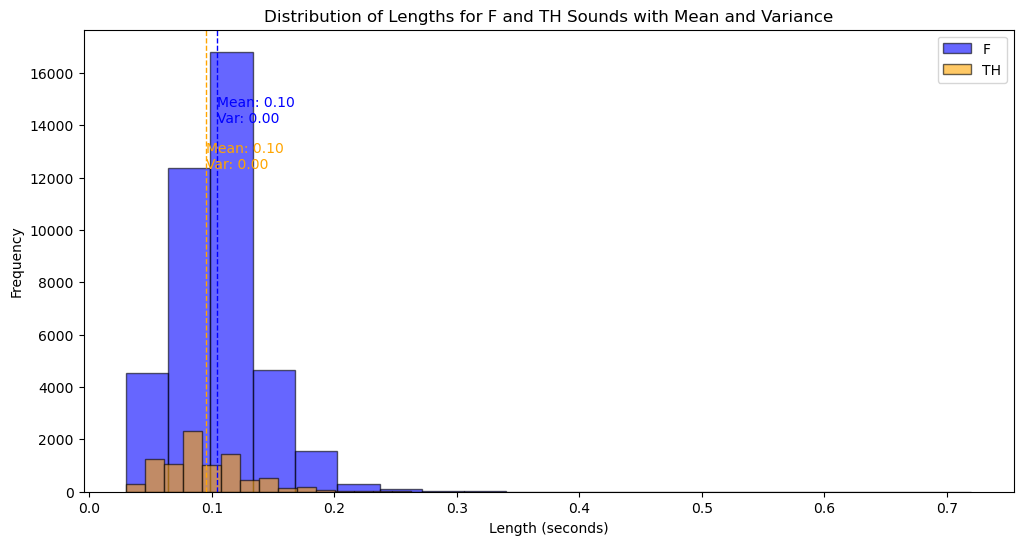

In [8]:
def visualize_sound_lengths_with_stats(df):
    # Filter the DataFrame for segments "S" and "SH"
    filtered_df = df[df['segment'].isin(to_investigate)]

    # Filterout whose next is not vowel
    filtered_df = filtered_df[filtered_df["next_segment"].isin(vowel_list)]
    
    # Calculate the lengths of each segment
    filtered_df['length'] = filtered_df['endTime'] - filtered_df['startTime']
    
    # Separate the lengths for "S" and "SH" sounds
    s_lengths = filtered_df[filtered_df['segment'] == to_investigate[0]]['length']
    sh_lengths = filtered_df[filtered_df['segment'] == to_investigate[1]]['length']
    
    # Calculate mean and variance
    s_mean = s_lengths.mean()
    s_variance = s_lengths.var()
    sh_mean = sh_lengths.mean()
    sh_variance = sh_lengths.var()
    
    # Plot the lengths
    plt.figure(figsize=(12, 6))
    plt.hist(s_lengths, bins=20, alpha=0.6, label=to_investigate[0], edgecolor='black', color='blue')
    plt.hist(sh_lengths, bins=20, alpha=0.6, label=to_investigate[1], edgecolor='black', color='orange')
    
    # Annotate mean and variance for "S"
    plt.axvline(s_mean, color='blue', linestyle='dashed', linewidth=1)
    plt.text(s_mean, plt.gca().get_ylim()[1] * 0.8, f'Mean: {s_mean:.2f}\nVar: {s_variance:.2f}', color='blue')

    # Annotate mean and variance for "SH"
    plt.axvline(sh_mean, color='orange', linestyle='dashed', linewidth=1)
    plt.text(sh_mean, plt.gca().get_ylim()[1] * 0.7, f'Mean: {sh_mean:.2f}\nVar: {sh_variance:.2f}', color='orange')

    plt.xlabel('Length (seconds)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Lengths for {to_investigate[0]} and {to_investigate[1]} Sounds with Mean and Variance')
    plt.legend()
    plt.show()

# Example usage
# Assuming df is your DataFrame
# visualize_sound_lengths(df)
visualize_sound_lengths_with_stats(guide_file_next_word)

# Now we want to construct a datasheet by selecting vowels based on speakers

Seeing that the number of tokens are quite unbalanced across the vowels and the total number is rather small. We decided to use "composed" sequence, i.e. the V1, S/SH and the V2 are selected from different sequences, not necessarily together. In this way, we *may* also reduce some co-articulation effects. 

However, we have to make sure that all selected tokens for one sequence belong to the same speaker. 

In [15]:
selected_segments = ["F", "TH"]
phitype_marker = ["F", "Th"]
exp_name = "fathi"

load full data

In [6]:
guide_file_next_word = pd.read_csv(os.path.join(src_, "guide_all_clean.csv"))

get vowel list for filtering: notice that this is "segment", with stress marking, this is because I used "segment" to construct "next_segment", but no worries, this will not affect other parts. 

In [7]:
vowel_list = []
for segment in ['AE1', 'ER0', 'AY1', 'IY0', 'AH1', 'AO1',
       'IY1', 'AW1', 'AH0', 'IH0', 
       'UW1', 'AY2', 'EH1', 'IH1', 'AA1', 'EY2',
       'S', 'G', 'UW2', 'OW0', 'OW2', 'SH', 'EY1', 'OW1', 'ZH', 'UW0',
       'B', 'EY0', 'UH1', 'JH', 'ER1', 'DH', 'EH0', 'EH2', 'IH2', 'TH',
       'AO0', 'AO2', 'AY0', 'AE2', 'AA2', 'AH2', 'OY1', 'AA0', 'HH',
       'ER2', 'AE0', 'UH2', 'IY2', 'OY0', 'AW2', 'OY2', 'UH0', 'AW0']: 
    if segment[-1].isdigit(): 
        vowel_list.append(segment)

Get the S/SH dfs and check size

In [8]:
S_df = guide_file_next_word[(guide_file_next_word["segment"] == selected_segments[0]) & (guide_file_next_word["next_segment"].isin(vowel_list))]
Sh_df = guide_file_next_word[(guide_file_next_word["segment"] == selected_segments[1]) & (guide_file_next_word["next_segment"].isin(vowel_list))]

len(S_df), len(Sh_df)

(40335, 8837)

In [9]:
# This means that in the S/Sh dataset, all speakers are involved. 
assert len(S_df["speaker"].unique() & Sh_df["speaker"].unique()) == len(S_df["speaker"].unique()) == len(Sh_df["speaker"].unique())

Construct dictionary to hold all the sub-dfs, including the vowels

In [10]:
df_dict = {
    selected_segments[0]: S_df, 
    selected_segments[1]: Sh_df
}

for vowel in ["AA", "AY", "IY", "UW", "AE", "EY"]:  # Now we only consider long vowels
    df_dict[vowel] = guide_file_next_word[(guide_file_next_word["segment_nostress"] == vowel)]

In [8]:
"""
Tentative rule for S phonotactics: 
"S": ["AA", "AH", "UW", "UH"]
"SH": ["IY", "IH", "AE", "EH"]
"""

'\nTentative rule for S phonotactics: \n"S": ["AA", "AH", "UW", "UH"]\n"SH": ["IY", "IH", "AE", "EH"]\n'

Function to construct a balanced dataset

In [11]:
def split_number_into_n_parts_randomized(number, n):
    base = np.floor(number / n)
    remainder = number % n
    random_indices = np.random.choice(n, remainder, replace=False)
    parts = base + (np.isin(np.arange(n), random_indices)).astype(int)
    return parts.astype(int)

def construct_VSV(dfs, target_S, vowels_list_pre, vowels_list_post):
    s_df = dfs[target_S]
    s_grouped = s_df.groupby('speaker')

    grouped_vowel_dfs = {vowel: dfs[vowel].groupby('speaker') for vowel in set(vowels_list_pre + vowels_list_post)}
    output = []
    # Iterate over each speaker group
    for speaker, s_tokens in s_grouped: 
        selected_vowels_dict = {}
        for sample_type, vowels_list in zip(["pre", "post"], [vowels_list_pre, vowels_list_post]): 
            selected_vowels = None
            length_list = split_number_into_n_parts_randomized(len(s_tokens), len(vowels_list))
            for idx, vowel in enumerate(vowels_list): 
                vowel_grouped = grouped_vowel_dfs[vowel]
                vowel_count = length_list[idx]
                if speaker in vowel_grouped.groups:
                    vowels = vowel_grouped.get_group(speaker)
                    if vowel_count > len(vowels): 
                        print(f"Warning: Not enough {vowel} vowels for speaker {speaker}")
                        allow_replace = True
                    else: 
                        allow_replace = False
                        
                    if selected_vowels is None: 
                        selected_vowels = vowels.sample(n=vowel_count, replace=allow_replace)
                    else: 
                        selected_vowels = pd.concat([selected_vowels, vowels.sample(n=vowel_count, replace=allow_replace)], ignore_index=True)
            selected_vowels_dict[sample_type] = selected_vowels

        # Create paired data
        for v_pre, s, v_post in zip(selected_vowels_dict["pre"].itertuples(), s_tokens.itertuples(), selected_vowels_dict["post"].itertuples()): 
            v_pre_duration = v_pre.endTime - v_pre.startTime
            s_duration = s.endTime - s.startTime
            v_post_duration = v_post.endTime - v_post.startTime
            output.append({
                'pre': v_pre.segment_nostress,
                'stop': s.segment_nostress,
                'vowel': v_post.segment_nostress,
                "pre_path": v_pre.phone_path,
                'stop_path': s.phone_path,
                'vowel_path': v_post.phone_path,
                'pre_startTime': 0,
                'pre_endTime': v_pre_duration,
                'stop_startTime': v_pre_duration,
                'stop_endTime': v_pre_duration + s_duration,
                'vowel_startTime': v_pre_duration + s_duration,
                'vowel_endTime': v_pre_duration + s_duration + v_post_duration,
                'ori_pre_startTime': v_pre.startTime,
                'ori_pre_endTime': v_pre.endTime,
                'ori_stop_startTime': s.startTime,
                'ori_stop_endTime': s.endTime,
                'ori_vowel_startTime': v_post.startTime,
                'ori_vowel_endTime': v_post.endTime,
                'speaker': s.speaker, # only one because all three must have the same speaker
                'wuid': s.wuid, 
                'pre_wuid': v_pre.wuid,
                'vowel_wuid': v_post.wuid
            })

    # Convert output list to dataframe
    output_df = pd.DataFrame(output)
    return output_df

In [12]:
full_vowel_set = ["AA", "AY", "IY", "UW", "AE", "EY"]
s_vowel_set = ["AA", "AY", "UW"]
sh_vowel_set = ["IY", "EY", "AE"]

s_df = construct_VSV(df_dict, selected_segments[0], full_vowel_set, s_vowel_set)  # larger
sh_df = construct_VSV(df_dict, selected_segments[1], full_vowel_set, sh_vowel_set)  # smaller

In [14]:
s_df["phi_type"] = phitype_marker[0]
sh_df["phi_type"] = phitype_marker[1]

In [16]:
s_df.to_csv(os.path.join(src_, f"phi-{exp_name}-{phitype_marker[0]}-guide.csv"), index=False)
sh_df.to_csv(os.path.join(src_, f"phi-{exp_name}-{phitype_marker[1]}-guide.csv"), index=False)

Check the quality of sound

In [17]:
# load the data
s_df = pd.read_csv(os.path.join(src_, f"phi-{exp_name}-{phitype_marker[0]}-guide.csv"))
sh_df = pd.read_csv(os.path.join(src_, f"phi-{exp_name}-{phitype_marker[1]}-guide.csv"))

In [18]:
audio_src_ = train_cut_phone_  # need to change to correct path

In [19]:
# row sound loader
def load_seq_sound(row, src_path, target_path): 
    pre_path = os.path.join(src_path, row["pre_path"])
    stop_path = os.path.join(src_path, row["stop_path"])
    vowel_path = os.path.join(src_path, row["vowel_path"])
    pre_sound, sr = torchaudio.load(pre_path)
    stop_sound, sr = torchaudio.load(stop_path)
    vowel_sound, sr = torchaudio.load(vowel_path)

    # combine the sounds
    combined_sound = torch.cat([pre_sound, stop_sound, vowel_sound], dim=1)
    torchaudio.save(target_path, combined_sound, sr, format="flac")
    return combined_sound, sr

def plot_spectrogram(waveform, sample_rate, target_path):
    # Generate the spectrogram
    spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate, 
                                                       n_fft=512, hop_length=128, 
                                                       n_mels=96)(waveform)
    spectrogram_db = torchaudio.transforms.AmplitudeToDB()(spectrogram)
    
    # Plot the spectrogram
    plt.figure(figsize=(10, 4))
    plt.imshow(spectrogram_db.squeeze().numpy(), origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(label='dB')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.tight_layout()
    # plt.show()
    plt.savefig(target_path)

In [20]:
target_ = os.path.join(src_, f"{exp_name}_samples/")
mk(target_)

We checked the sound quality of the constructed items. At least as a pilot run, we may use it. 

/tmp/ipykernel_4181718/2208959954.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


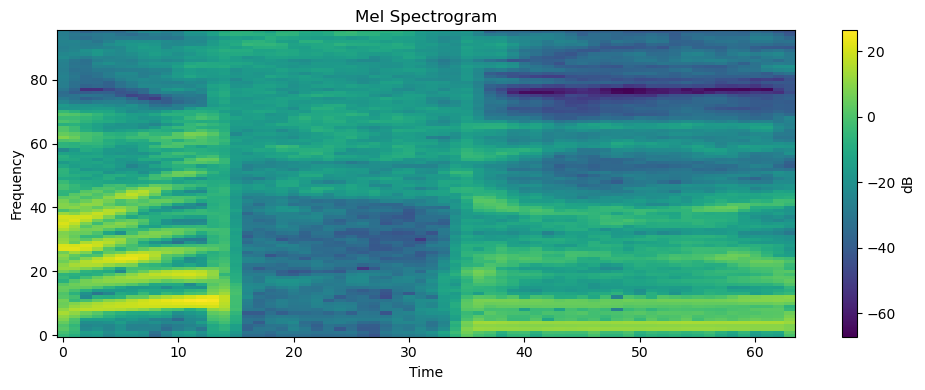

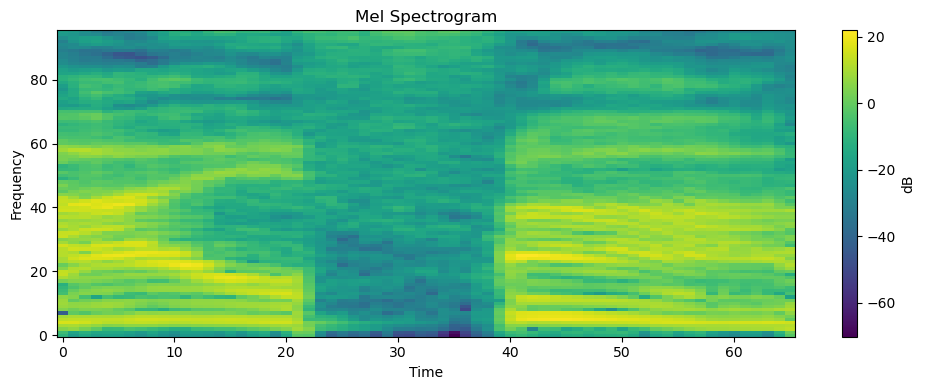

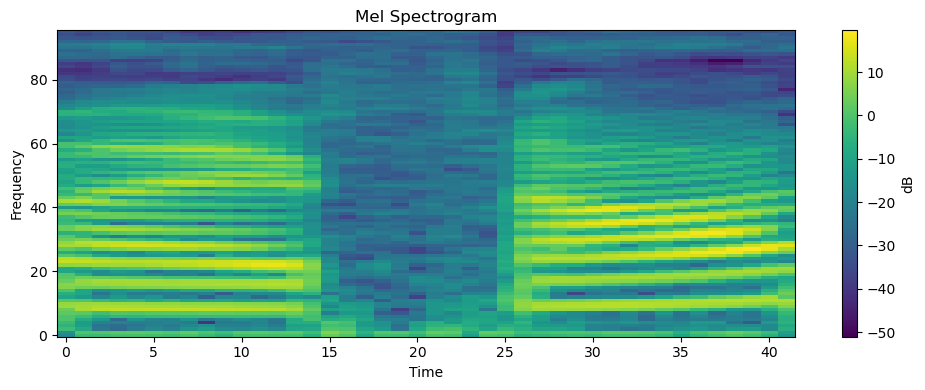

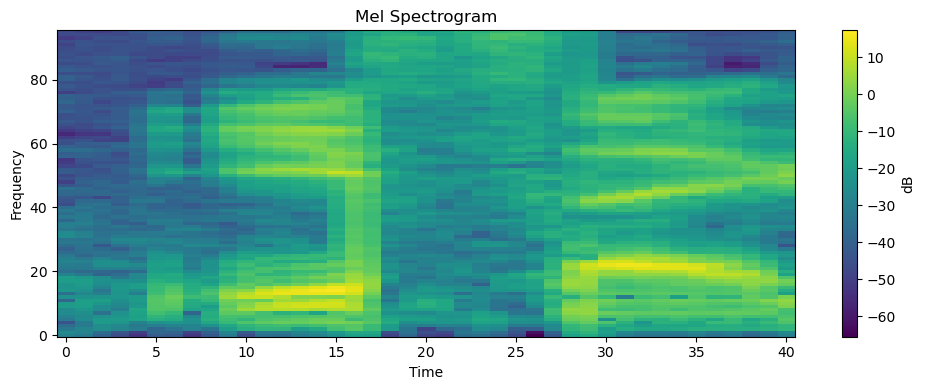

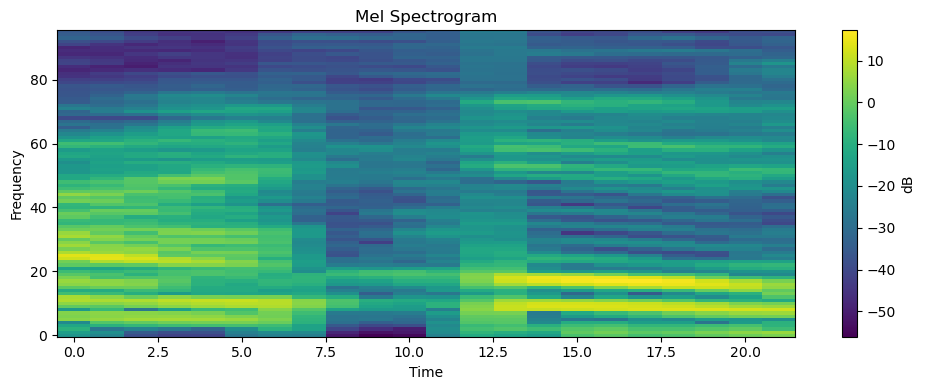

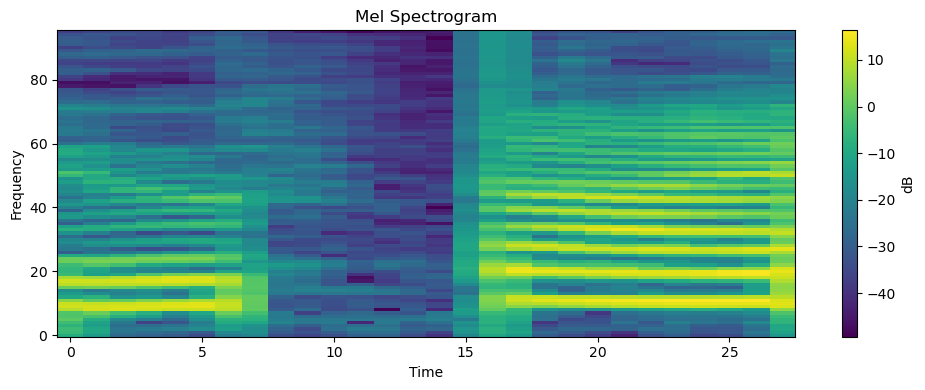

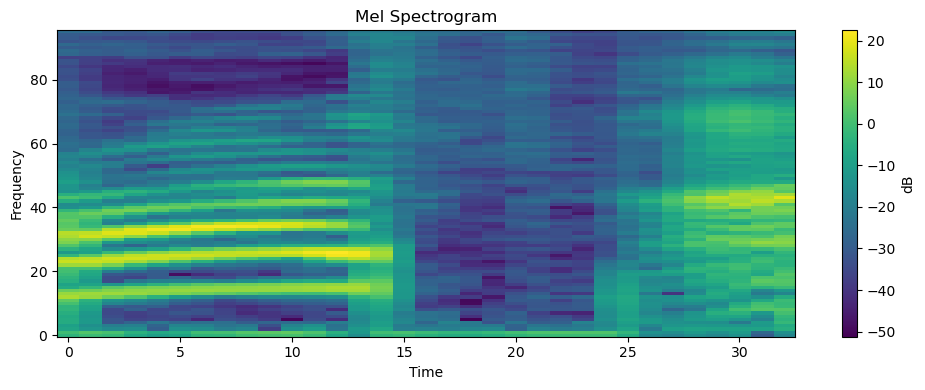

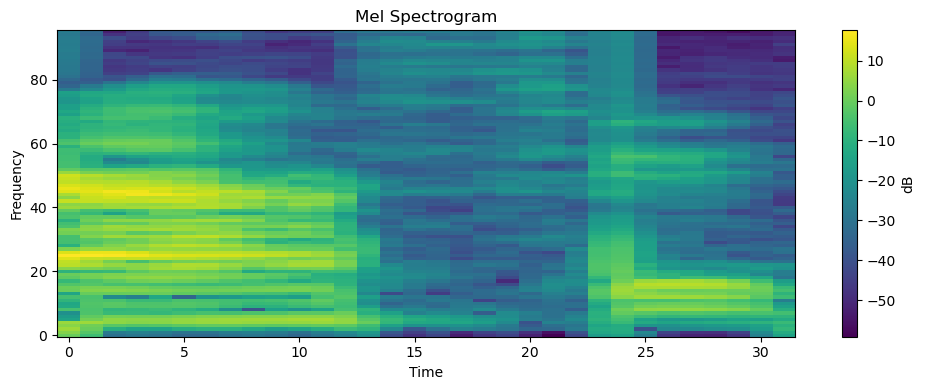

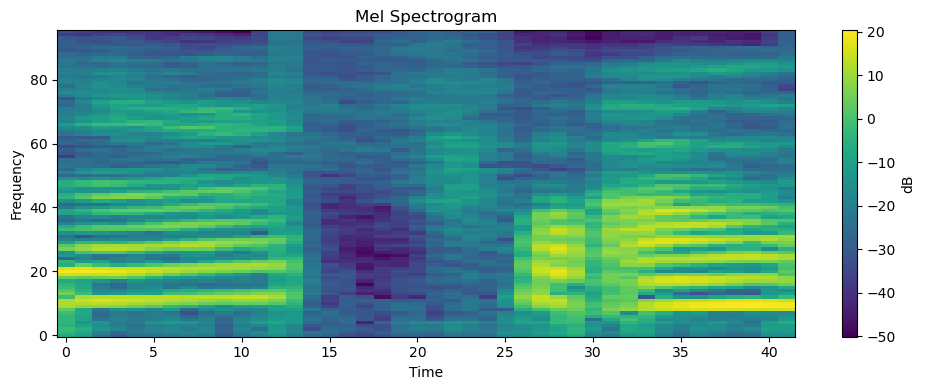

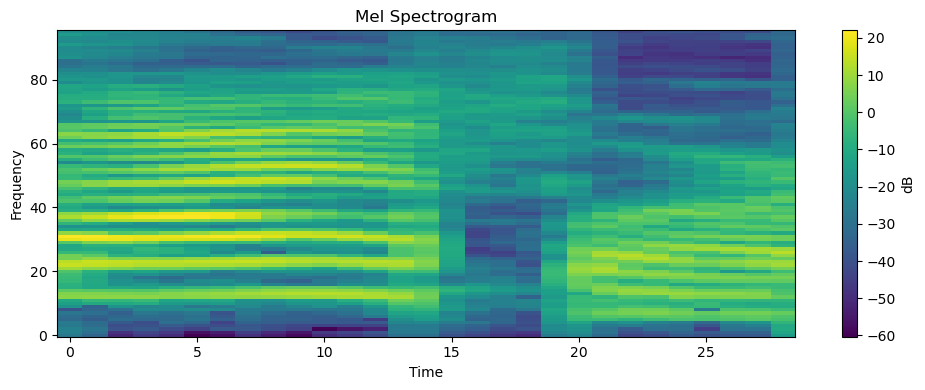

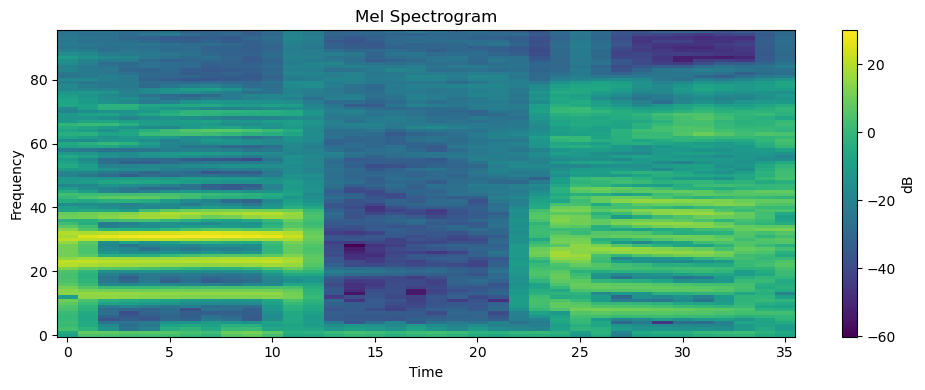

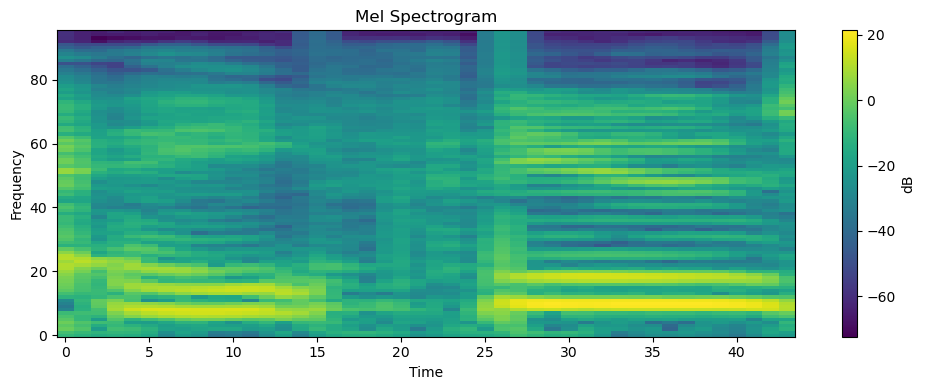

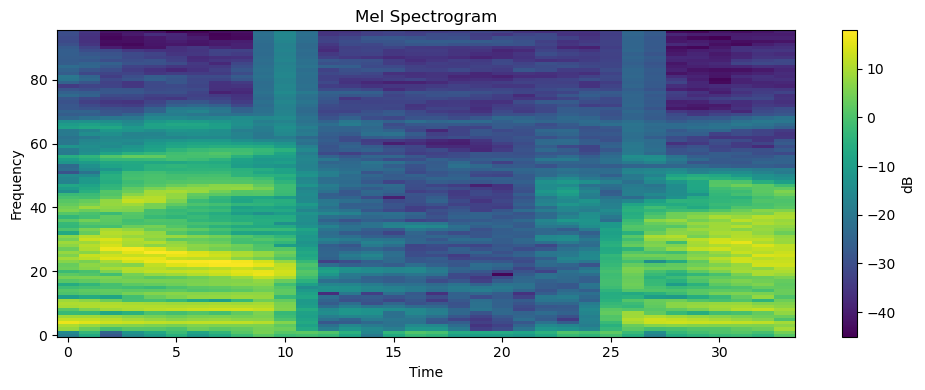

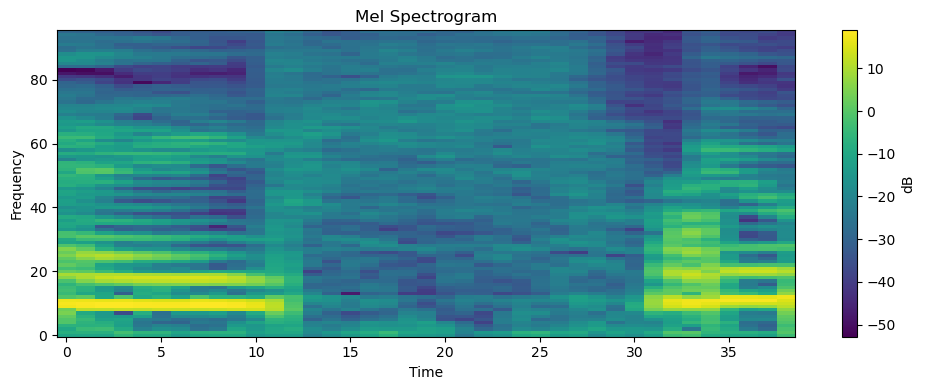

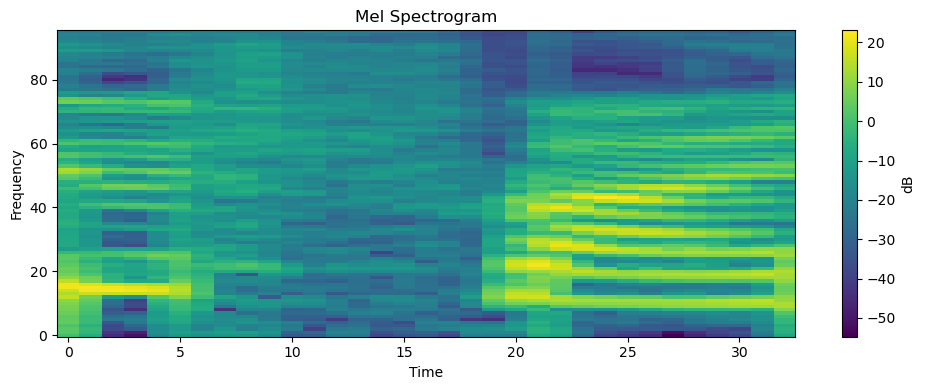

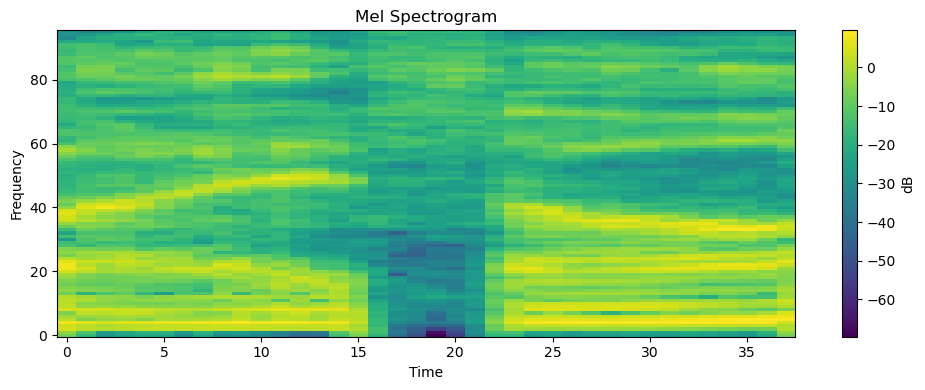

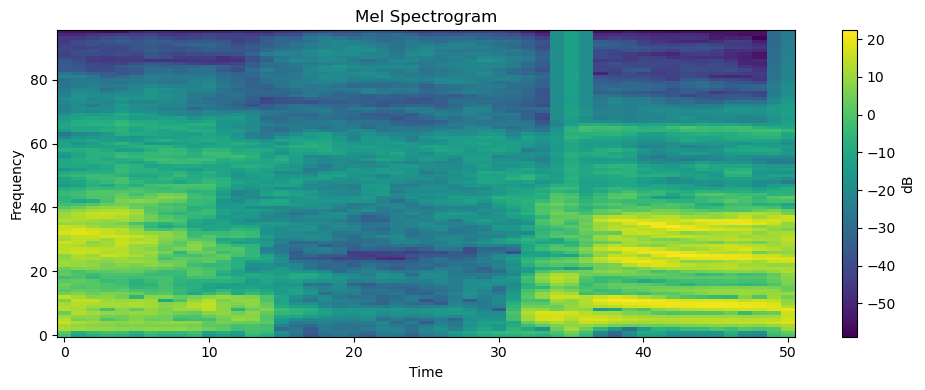

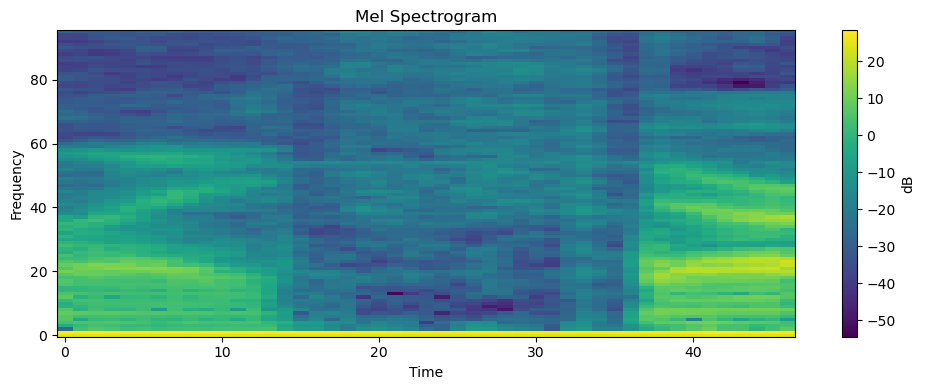

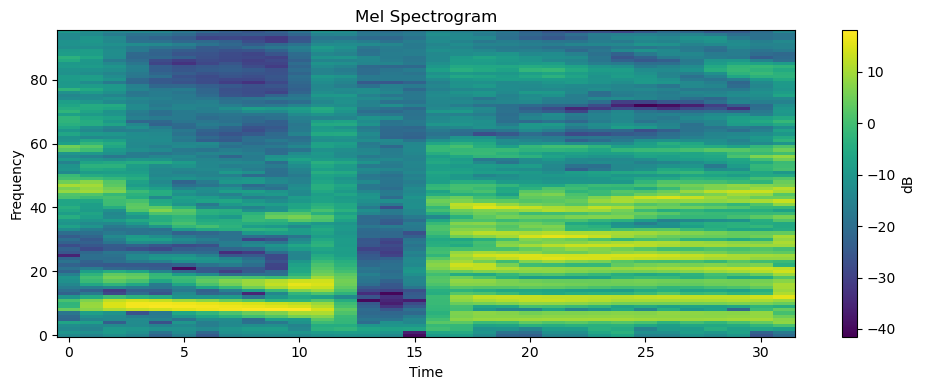

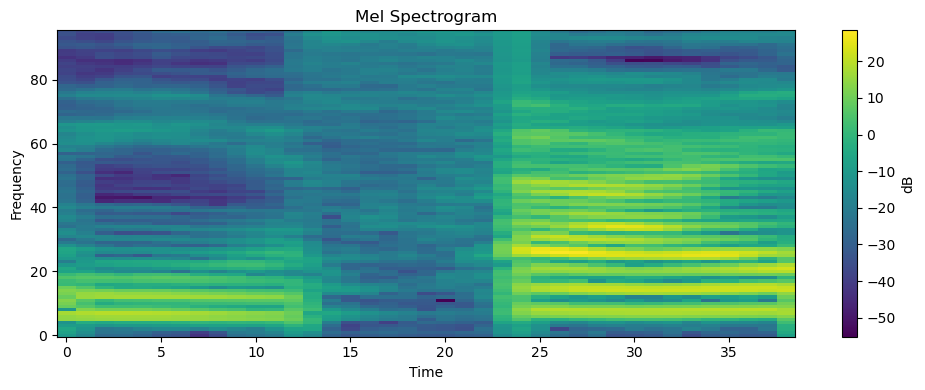

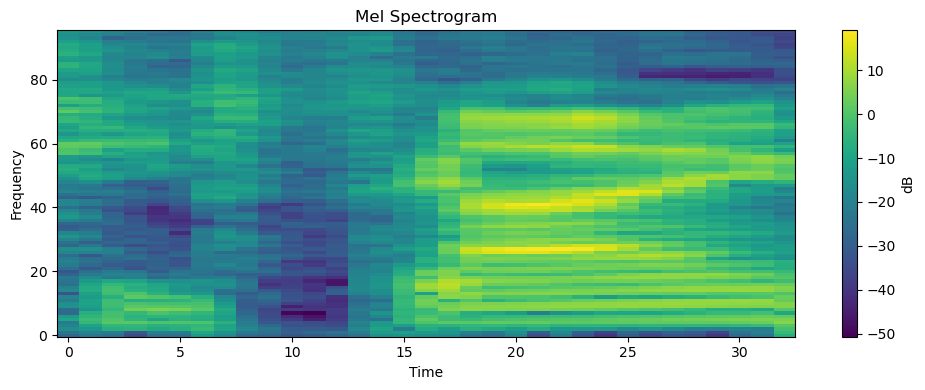

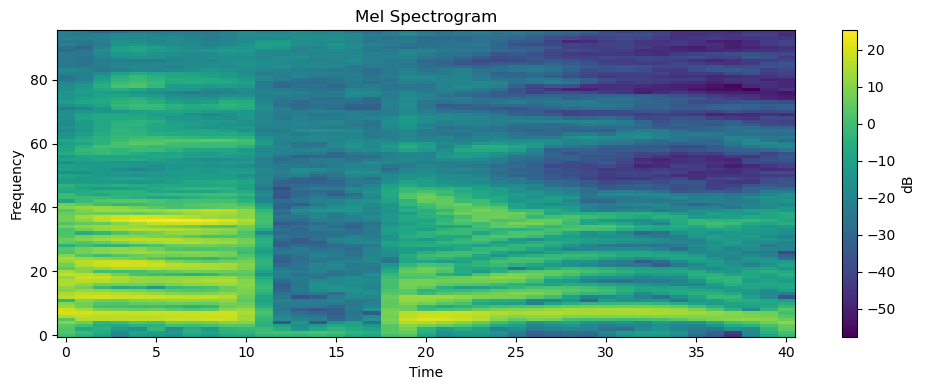

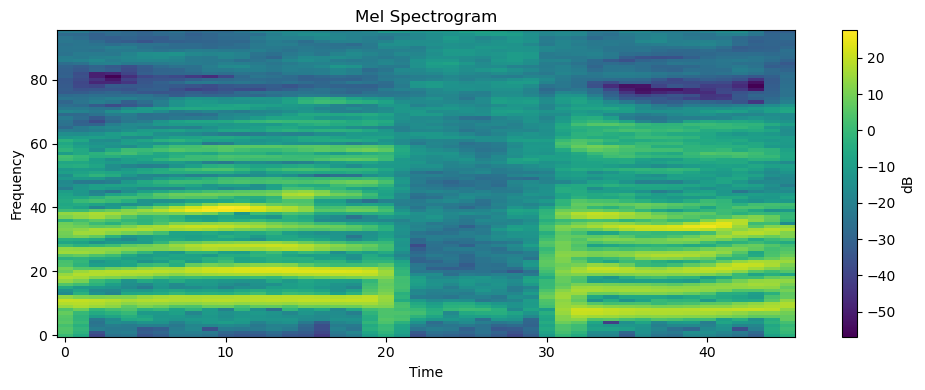

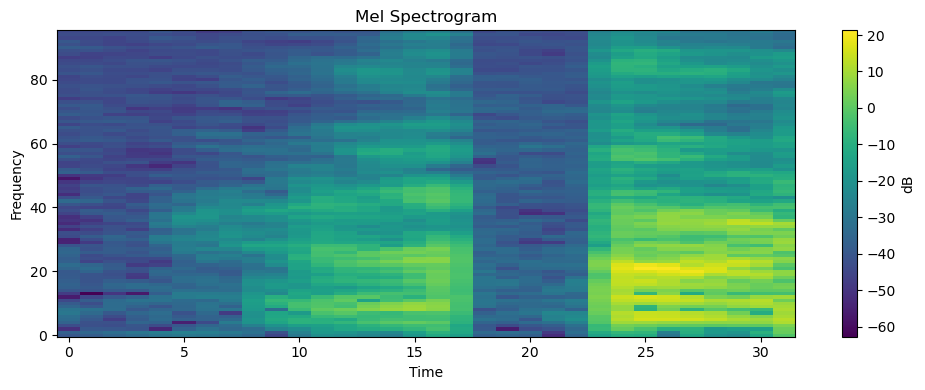

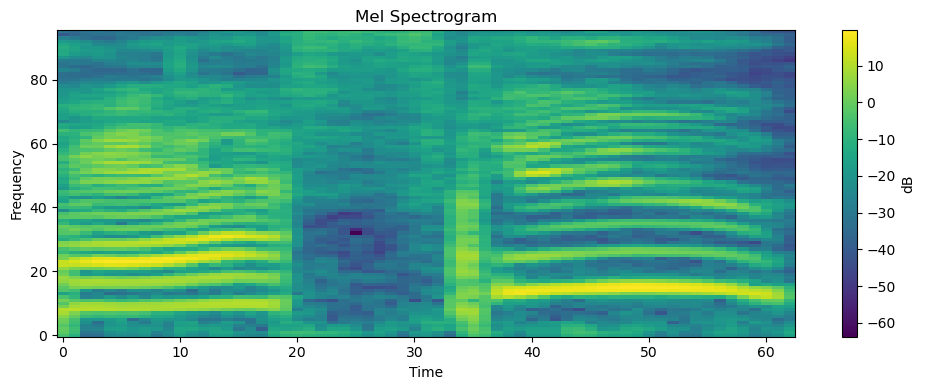

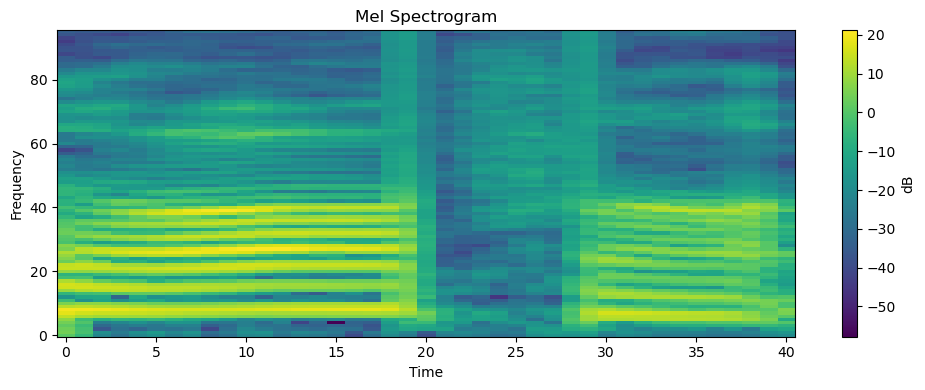

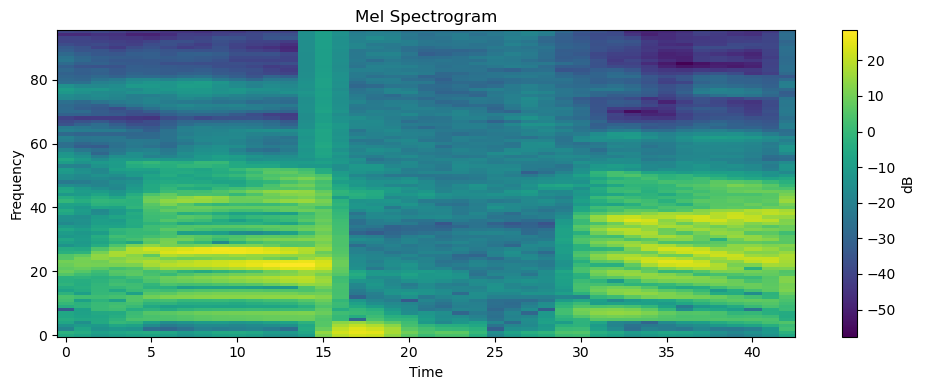

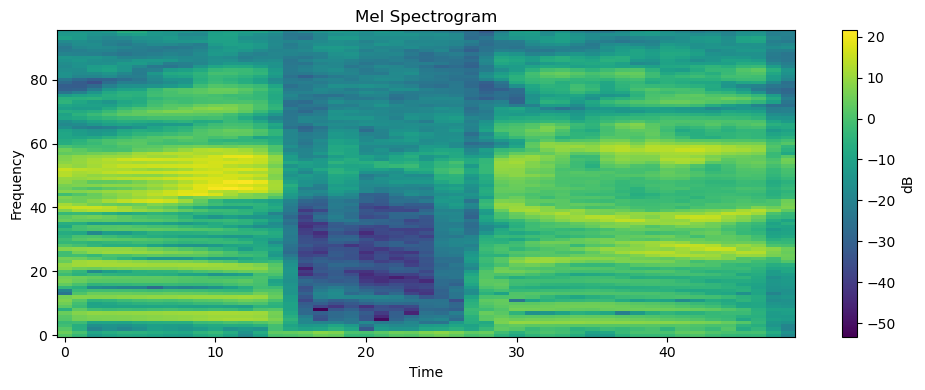

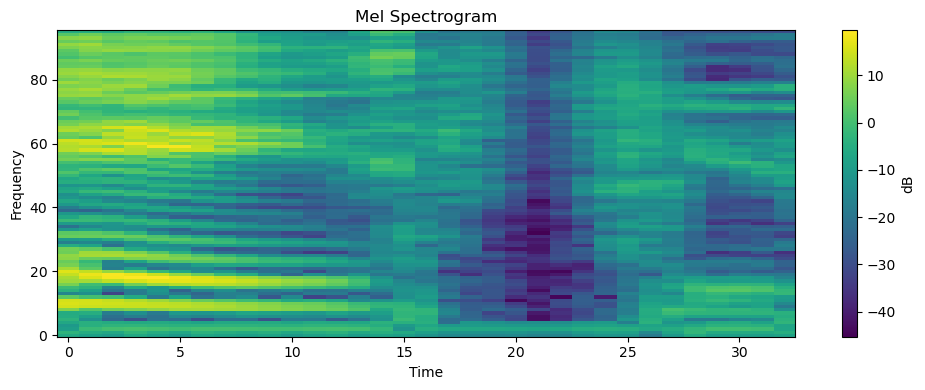

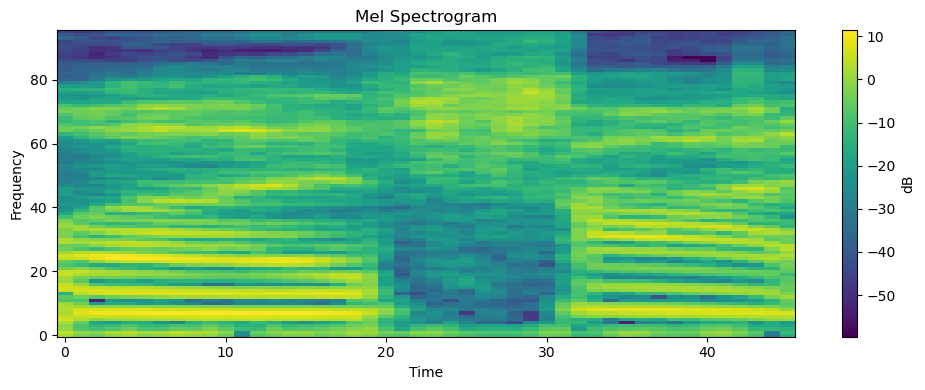

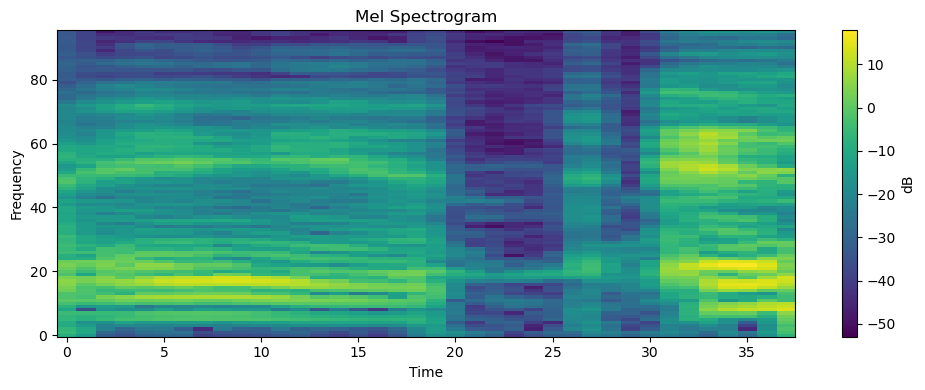

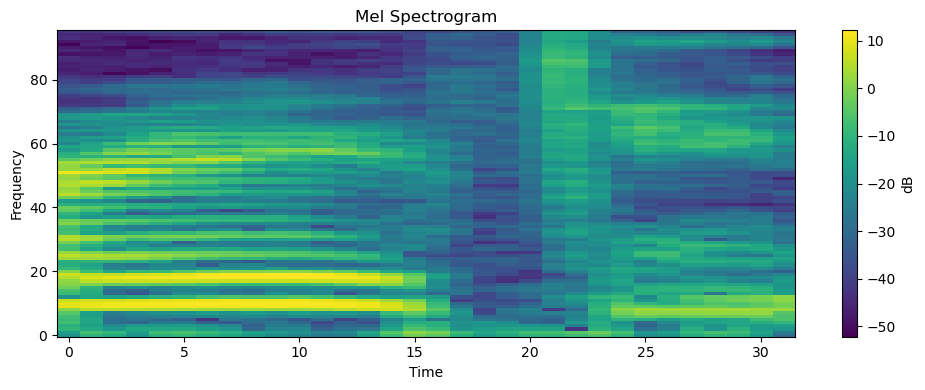

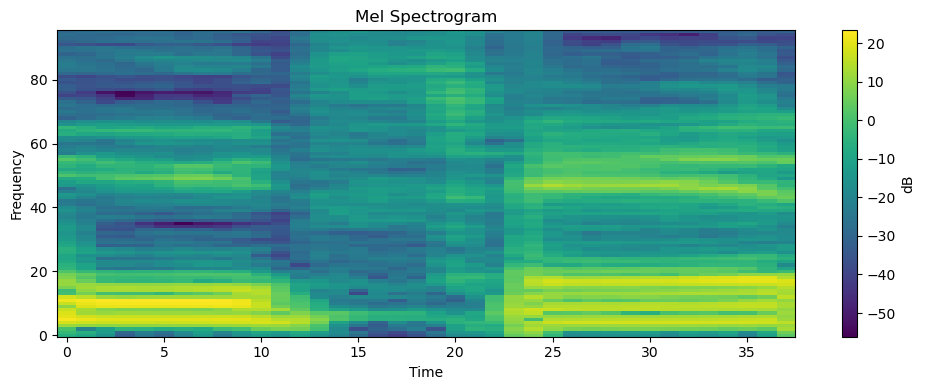

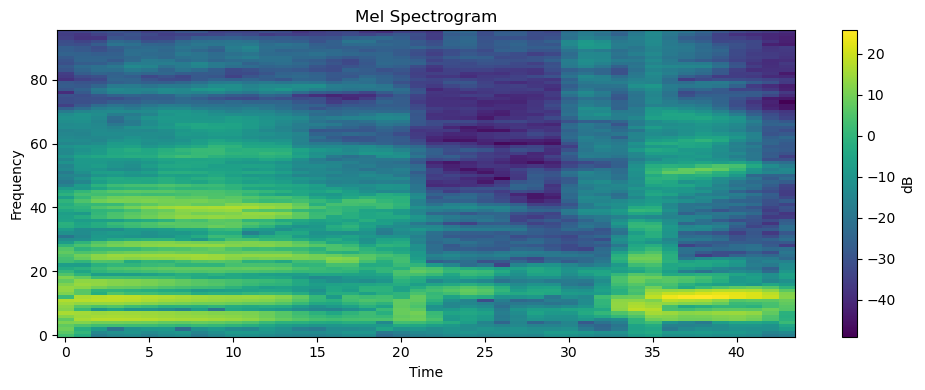

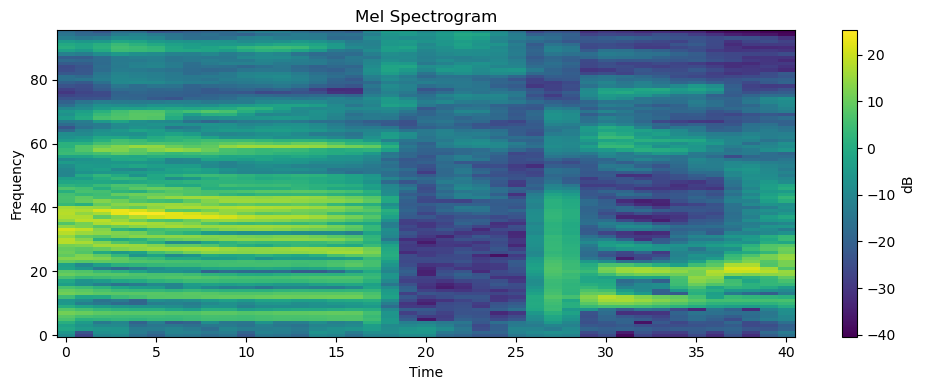

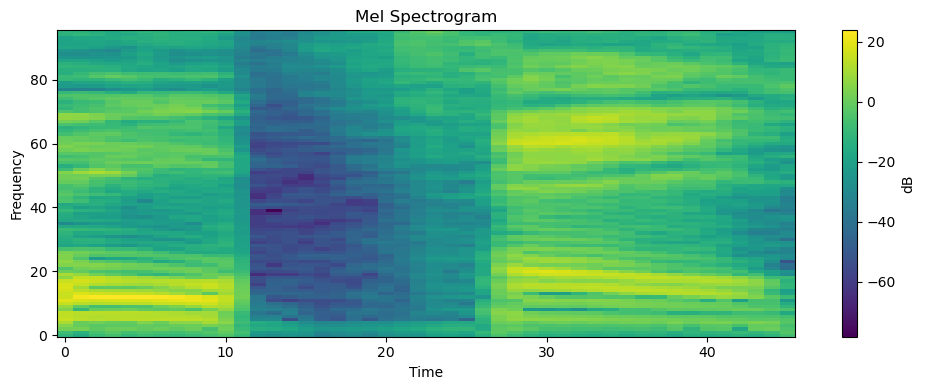

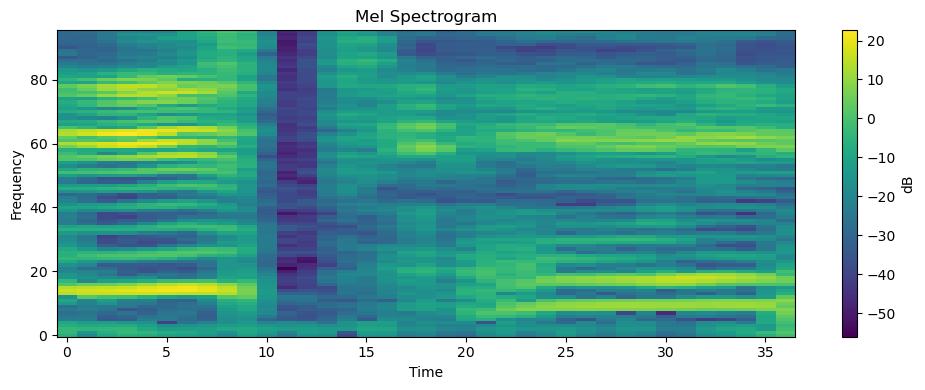

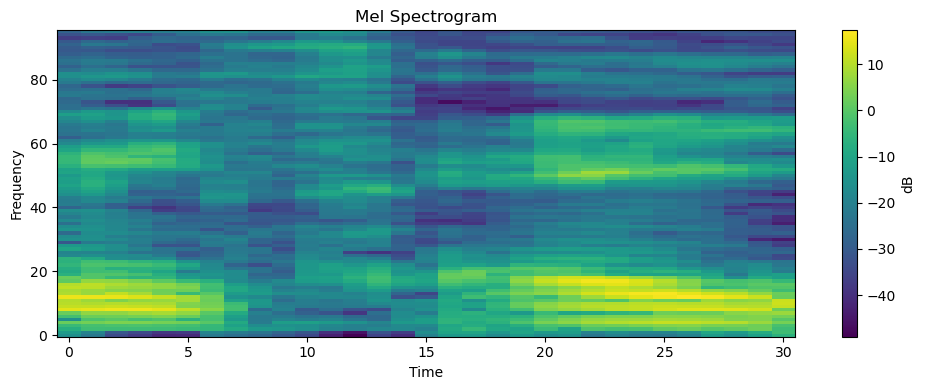

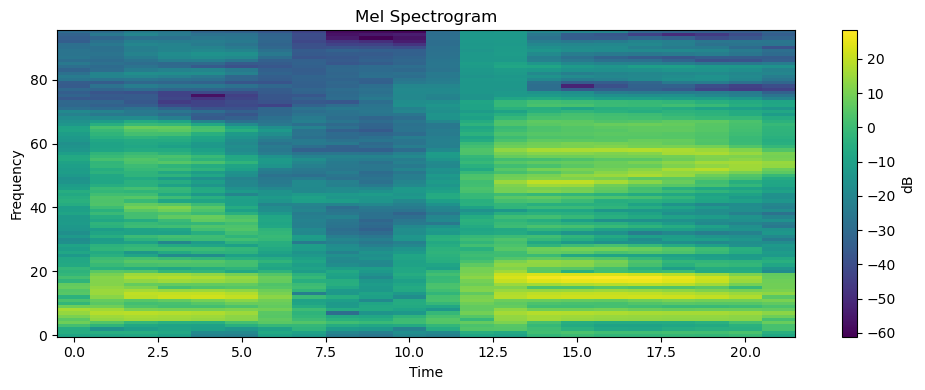

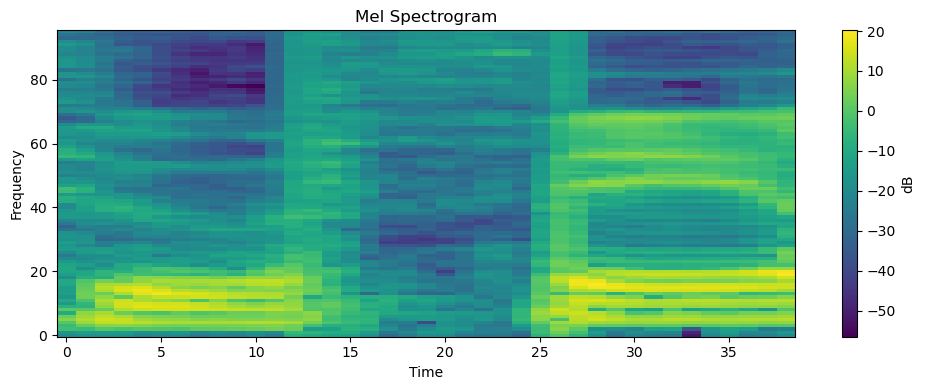

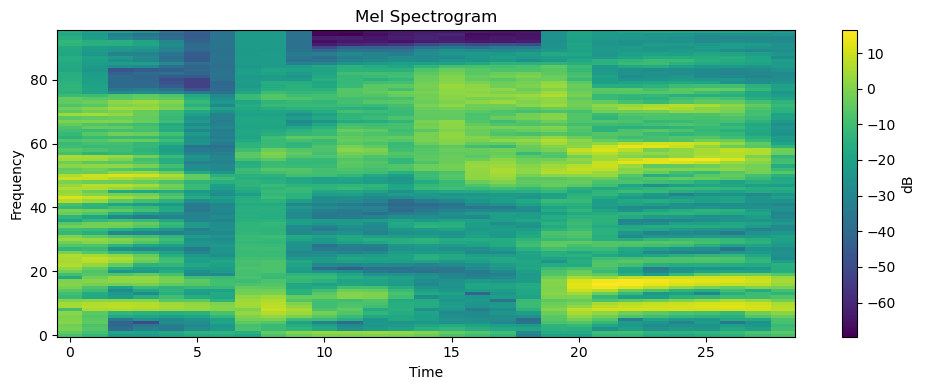

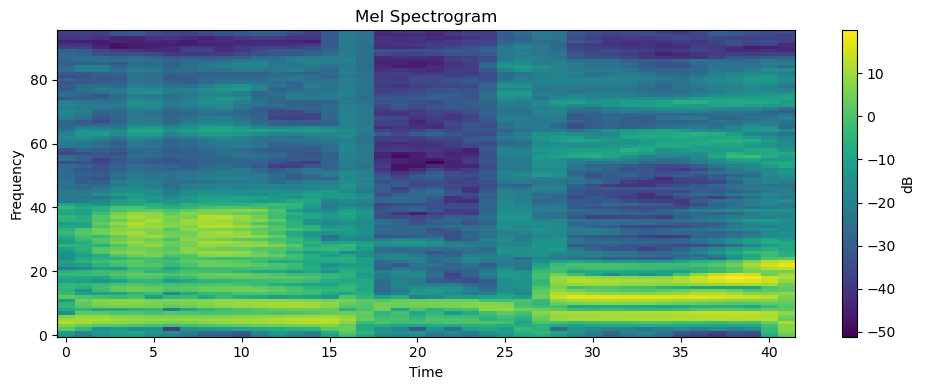

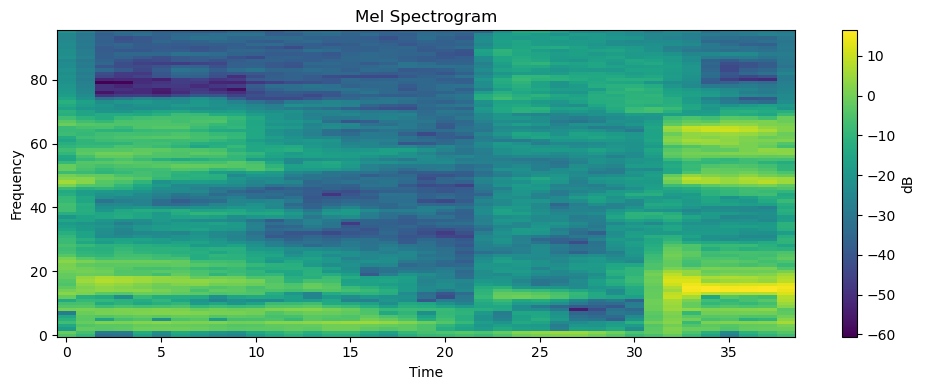

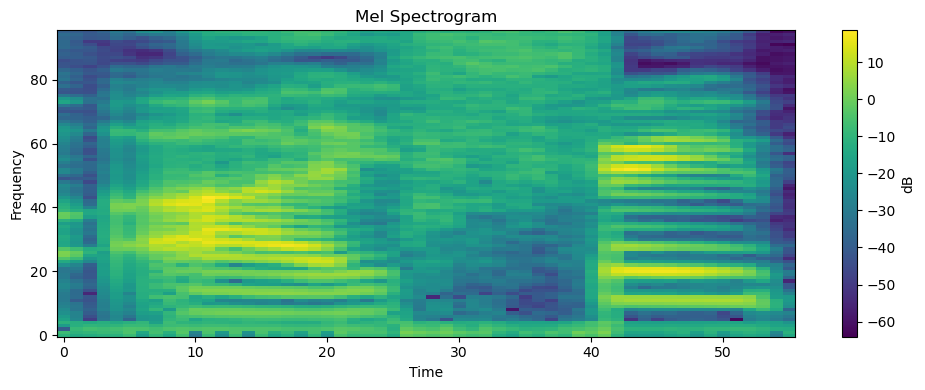

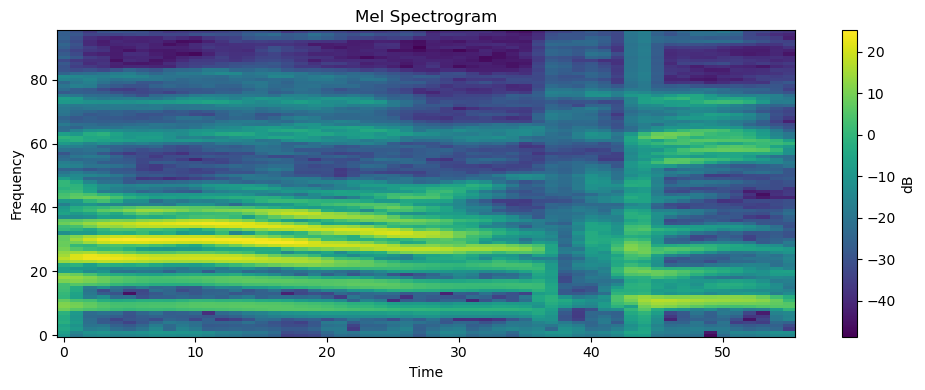

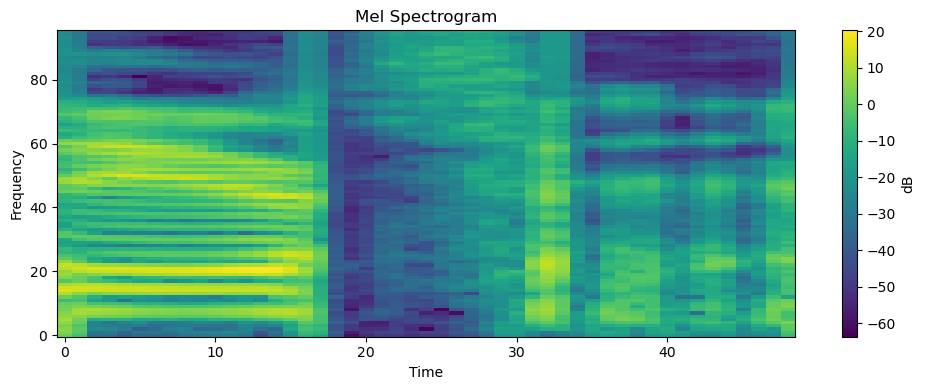

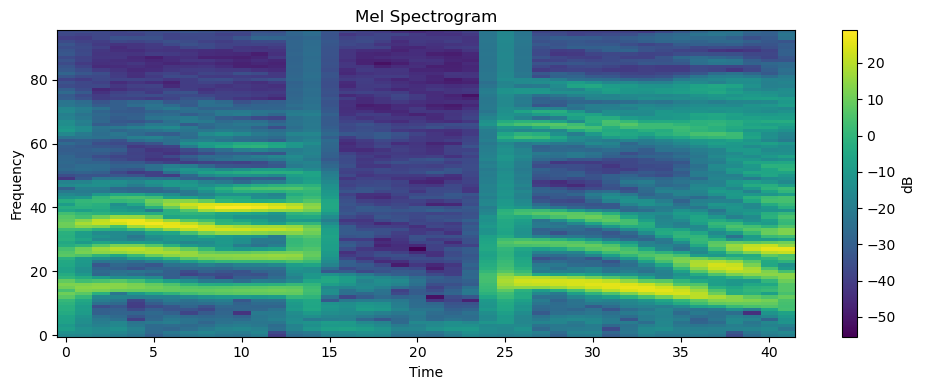

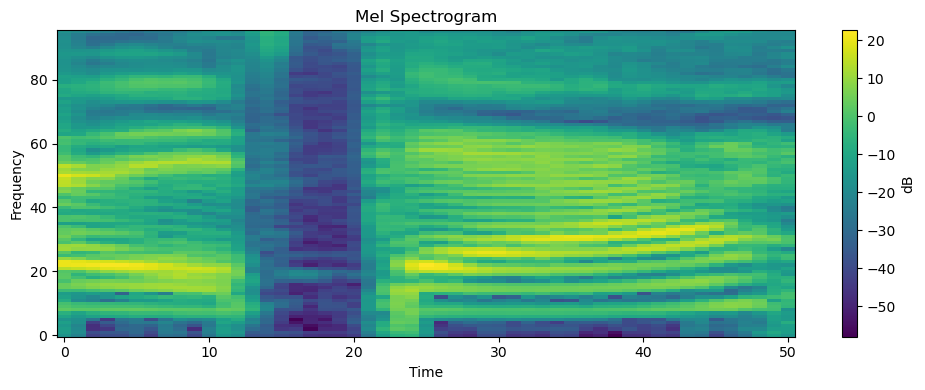

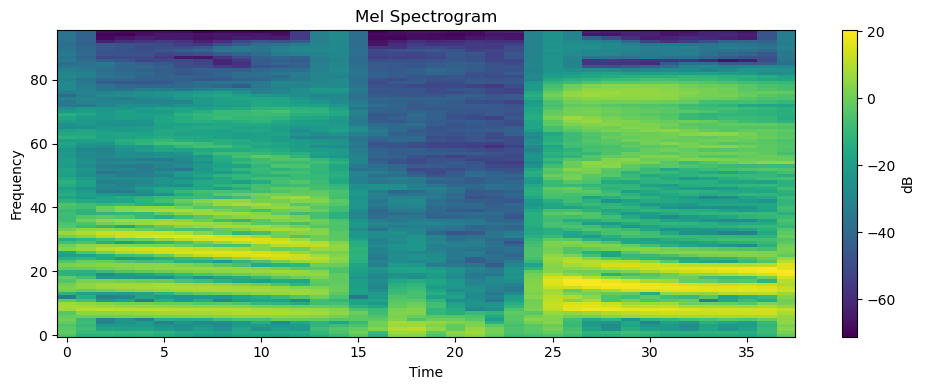

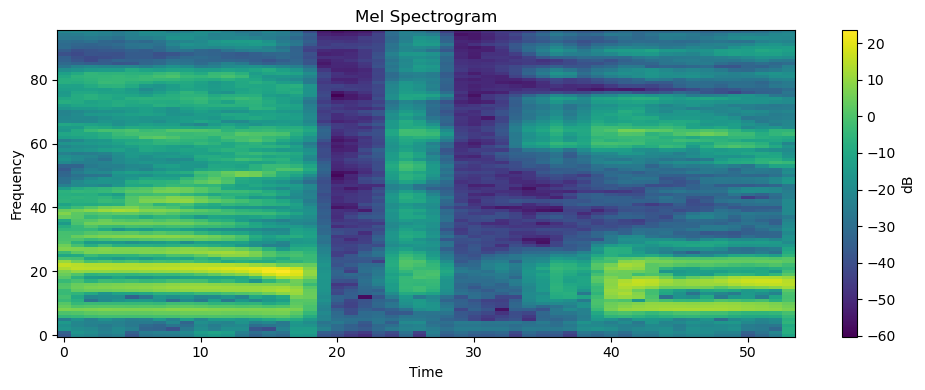

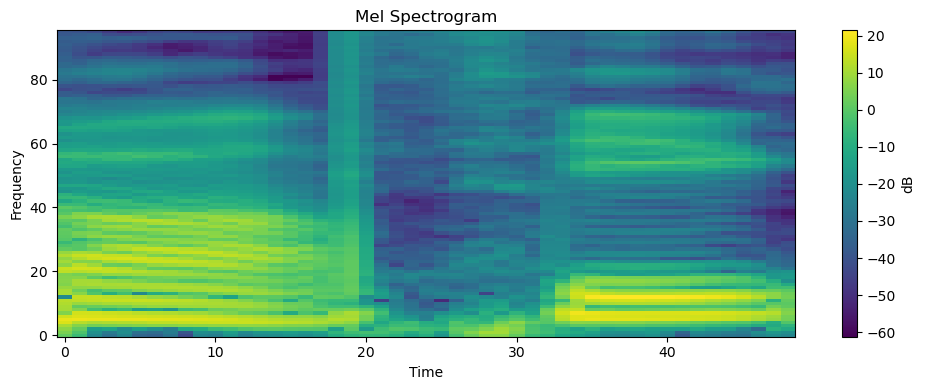

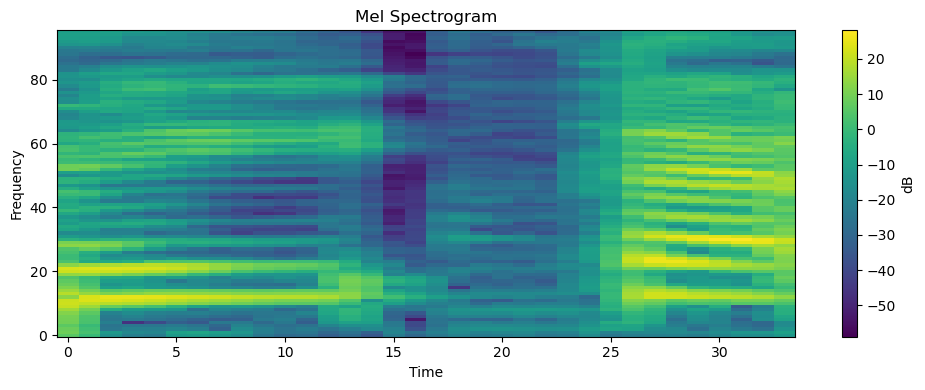

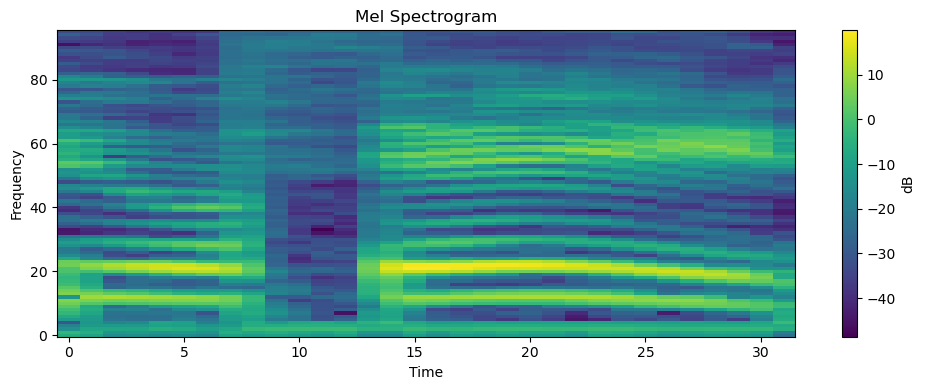

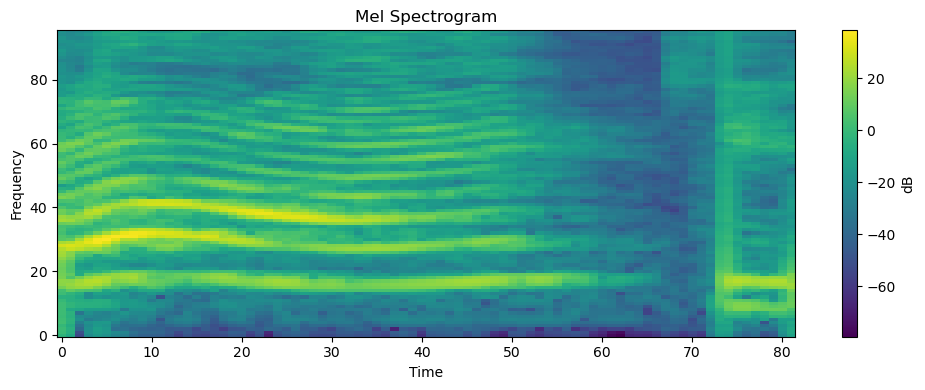

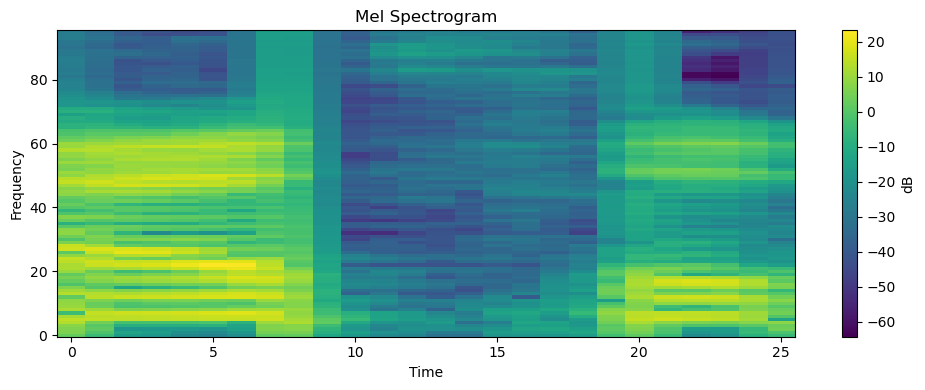

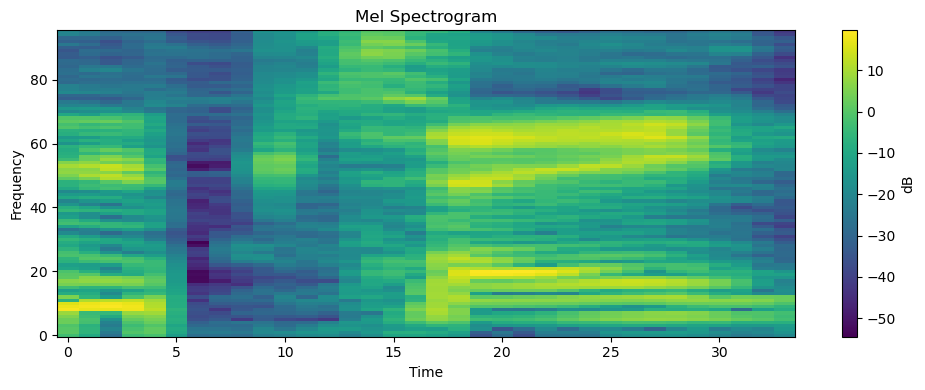

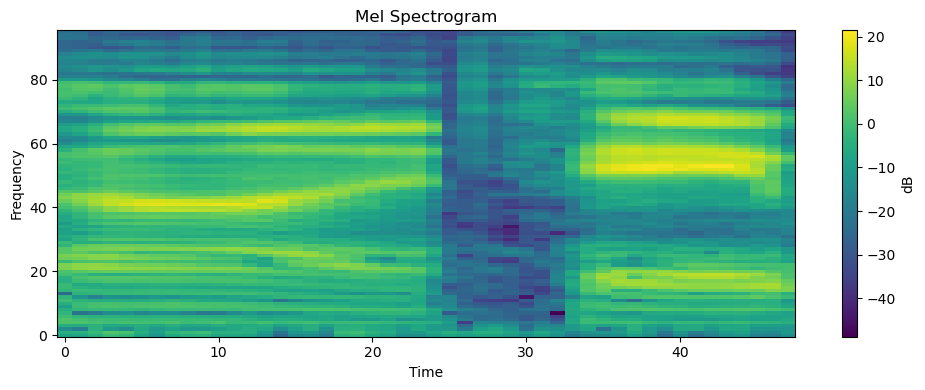

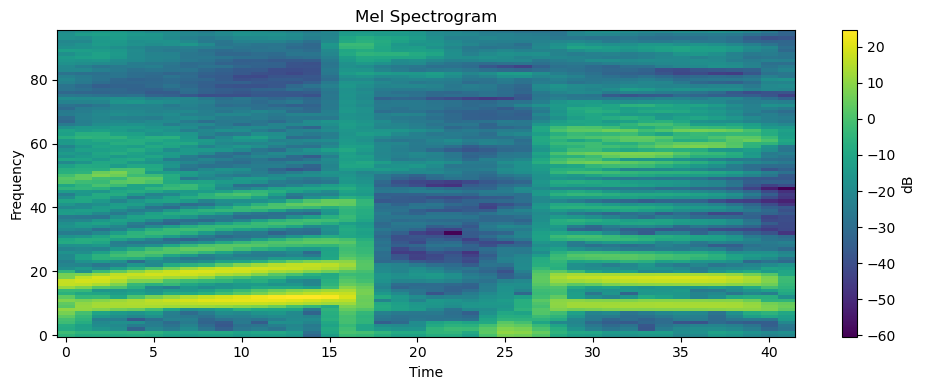

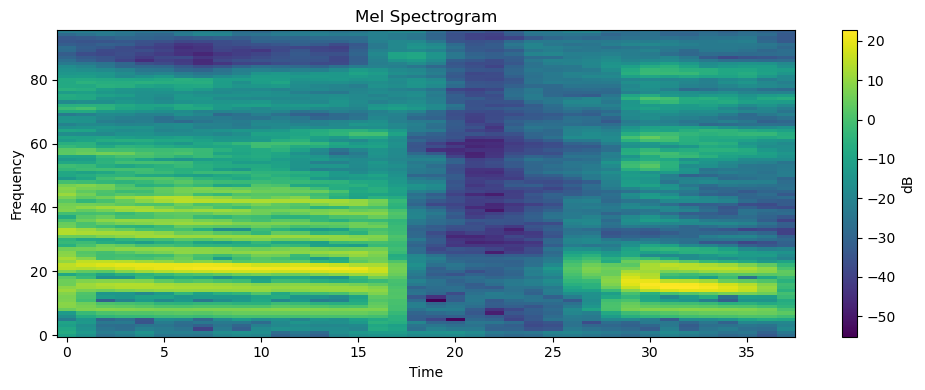

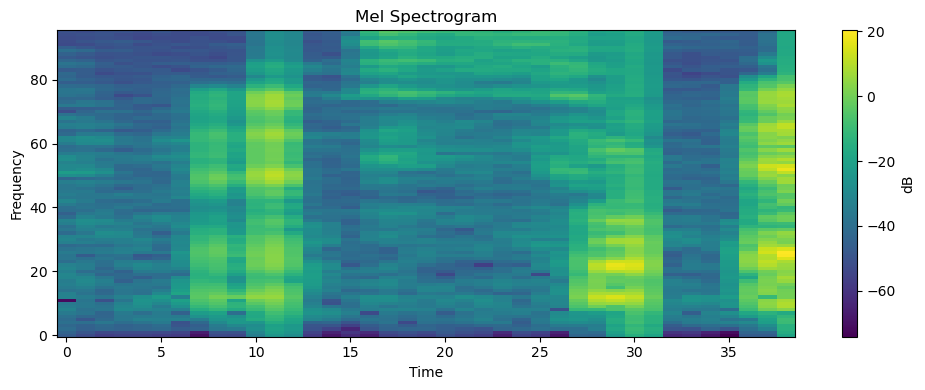

In [21]:
# randomly get 1000 samples
s_df_sample = s_df.sample(n=30)
sh_df_sample = sh_df.sample(n=30)

# save the sounds
for i, row in s_df_sample.iterrows(): 
    target_path = os.path.join(target_, f"S_{i}.flac")
    combined_sound, sr = load_seq_sound(row, audio_src_, target_path)
    plot_spectrogram(combined_sound, sr, target_path.replace(".flac", ".png"))
    

for i, row in sh_df_sample.iterrows():  
    target_path = os.path.join(target_, f"Sh_{i}.flac")
    combined_sound, sr = load_seq_sound(row, audio_src_, target_path)
    plot_spectrogram(combined_sound, sr, target_path.replace(".flac", ".png"))

## Grouping of Vowel into Speakers

# Trials

In [14]:
import pandas as pd
import numpy as np

Data Prepare

In [35]:
# Creating a sample dataframe for testing
data = {
    'segment_nostress': ['S', 'A', 'S', 'E', 'S', 'I', 'U', 'A', 'E', 'S', 'O', 'U', 'E', 'I', 'S'],
    'startTime': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5],
    'endTime': [0.8, 1.3, 1.8, 2.3, 2.8, 3.3, 3.8, 4.3, 4.8, 5.3, 5.8, 6.3, 6.8, 7.3, 7.8],
    'speaker': ['speaker1', 'speaker1', 'speaker2', 'speaker2', 'speaker1', 'speaker3', 'speaker3', 'speaker2', 'speaker1', 'speaker3', 'speaker1', 'speaker2', 'speaker3', 'speaker3', 'speaker3'],
    'path': ['path1', 'path2', 'path3', 'path4', 'path5', 'path6', 'path7', 'path8', 'path9', 'path10', 'path11', 'path12', 'path13', 'path14', 'path15'],
}

# Creating the dataframe
test_df = pd.DataFrame(data)
test_df

,segment_nostress,startTime,endTime,speaker,path
0,S,0.5,0.8,speaker1,path1
1,A,1.0,1.3,speaker1,path2
2,S,1.5,1.8,speaker2,path3
3,E,2.0,2.3,speaker2,path4
4,S,2.5,2.8,speaker1,path5
5,I,3.0,3.3,speaker3,path6
6,U,3.5,3.8,speaker3,path7
7,A,4.0,4.3,speaker2,path8
8,E,4.5,4.8,speaker1,path9
9,S,5.0,5.3,speaker3,path10


Functions

In [ ]:
def split_number_into_n_parts_randomized(number, n):
    base = np.floor(number / n)
    remainder = number % n
    random_indices = np.random.choice(n, remainder, replace=False)
    parts = base + (np.isin(np.arange(n), random_indices)).astype(int)
    return parts.astype(int)

In [37]:
df_dict = {
}

for vowel in ["S", "A", "E", "I", "U", "O"]:
    df_dict[vowel] = test_df[(test_df["segment_nostress"] == vowel)]

In [ ]:
def pair_stop_and_vowel(dfs, vowels_list):
    s_df = dfs["S"]
    # vowel_df = pd.concat(vowel_df_list, ignore_index=True)
    
    # Group by speaker and initialize output dataframe
    s_grouped = s_df.groupby('speaker')
    grouped_vowel_dfs = {vowel: dfs[vowel].groupby('speaker') for vowel in vowels_list}
    # vowel_grouped = vowel_df.groupby('speaker')
    output = []

    # Iterate over each speaker group
    for speaker, s_tokens in s_grouped: 
        selected_vowels = None
        length_list = split_number_into_n_parts_randomized(len(s_tokens), len(vowels_list))
        for idx, vowel in enumerate(vowels_list): 
            vowel_grouped = grouped_vowel_dfs[vowel]
            vowel_count = length_list[idx]
            if speaker in vowel_grouped.groups:
                vowels = vowel_grouped.get_group(speaker)
                if vowel_count > len(vowels): 
                    print(f"Warning: Not enough {vowel} vowels for speaker {speaker}")
                    allow_replace = True
                else: 
                    allow_replace = False
                    
                if selected_vowels is None: 
                    selected_vowels = vowels.sample(n=vowel_count, replace=allow_replace)
                else: 
                    selected_vowels = pd.concat([selected_vowels, vowels.sample(n=vowel_count, replace=allow_replace)], ignore_index=True)

        # Create paired data
        for s, v in zip(s_tokens.itertuples(), selected_vowels.itertuples()):
            output.append({
                'stop': s.segment_nostress,
                'vowel': v.segment_nostress,
                'stop_startTime': s.startTime,
                'stop_endTime': s.endTime,
                'vowel_startTime': v.startTime,
                'vowel_endTime': v.endTime,
                'stop_path': s.path,
                'vowel_path': v.path
            })

    # Convert output list to dataframe
    output_df = pd.DataFrame(output)
    return output_df

# Example usage
vowels_list = ['A', 'E']  # Replace with your list of vowels 'I', 'O', 'U'
output_df = pair_stop_and_vowel(df_dict, vowels_list)


,stop,vowel,stop_startTime,stop_endTime,vowel_startTime,vowel_endTime,stop_path,vowel_path
0,S,A,0.5,0.8,1.0,1.3,path1,path2
1,S,E,2.5,2.8,4.5,4.8,path5,path9
2,S,E,1.5,1.8,2.0,2.3,path3,path4
3,S,E,5.0,5.3,6.5,6.8,path10,path13


In [57]:
def construct_VSV(dfs, target_S, vowels_list_pre, vowels_list_post):
    s_df = dfs[target_S]
    s_grouped = s_df.groupby('speaker')

    grouped_vowel_dfs = {vowel: dfs[vowel].groupby('speaker') for vowel in set(vowels_list_pre + vowels_list_post)}
    output = []
    # Iterate over each speaker group
    for speaker, s_tokens in s_grouped: 
        selected_vowels_dict = {}
        for sample_type, vowels_list in zip(["pre", "post"], [vowels_list_pre, vowels_list_post]): 
            selected_vowels = None
            length_list = split_number_into_n_parts_randomized(len(s_tokens), len(vowels_list))
            for idx, vowel in enumerate(vowels_list): 
                vowel_grouped = grouped_vowel_dfs[vowel]
                vowel_count = length_list[idx]
                if speaker in vowel_grouped.groups:
                    vowels = vowel_grouped.get_group(speaker)
                    if vowel_count > len(vowels): 
                        print(f"Warning: Not enough {vowel} vowels for speaker {speaker}")
                        allow_replace = True
                    else: 
                        allow_replace = False
                        
                    if selected_vowels is None: 
                        selected_vowels = vowels.sample(n=vowel_count, replace=allow_replace)
                    else: 
                        selected_vowels = pd.concat([selected_vowels, vowels.sample(n=vowel_count, replace=allow_replace)], ignore_index=True)
            selected_vowels_dict[sample_type] = selected_vowels

        # Create paired data
        for v_pre, s, v_post in zip(selected_vowels_dict["pre"].itertuples(), s_tokens.itertuples(), selected_vowels_dict["post"].itertuples()):
            output.append({
                'pre': v_pre.segment_nostress,
                'stop': s.segment_nostress,
                'vowel': v_post.segment_nostress,
                "pre_path": v_pre.path,
                'stop_path': s.path,
                'vowel_path': v_post.path,
                'pre_startTime': v_pre.startTime,
                'pre_endTime': v_pre.endTime,
                'stop_startTime': s.startTime,
                'stop_endTime': s.endTime,
                'vowel_startTime': v_post.startTime,
                'vowel_endTime': v_post.endTime,
                'speaker': s.speaker, 
                # 'wuid': s.wuid
            })

    # Convert output list to dataframe
    output_df = pd.DataFrame(output)
    return output_df

# Example usage
vowels_list_pre = ['A', 'E', 'I', 'O', 'U']  # Replace with your list of vowels 'I', 'O', 'U'
vowels_list_post = ['A', 'E']  # Replace with your list of vowels 'I', 'O', 'U'
output_df = construct_VSV(df_dict, "S", vowels_list_pre, vowels_list_post)
output_df

,pre,stop,vowel,pre_path,stop_path,vowel_path,pre_startTime,pre_endTime,stop_startTime,stop_endTime,vowel_startTime,vowel_endTime,speaker
0,A,S,A,path2,path1,path2,1.0,1.3,0.5,0.8,1.0,1.3,speaker1
1,E,S,E,path9,path5,path9,4.5,4.8,2.5,2.8,4.5,4.8,speaker1
2,E,S,E,path4,path3,path4,2.0,2.3,1.5,1.8,2.0,2.3,speaker2
3,E,S,E,path13,path10,path13,6.5,6.8,5.0,5.3,6.5,6.8,speaker3


In [19]:
def split_number_into_n_parts(number, n):
    return (np.floor(number / n) + (np.arange(n) < (number % n)).astype(int))

def split_number_into_n_parts_randomized(number, n):
    base = np.floor(number / n)
    remainder = number % n
    random_indices = np.random.choice(n, remainder, replace=False)
    parts = base + (np.isin(np.arange(n), random_indices)).astype(int)
    return parts

split_number_into_n_parts(105, 24), split_number_into_n_parts_randomized(105, 24)

(array([5., 5., 5., 5., 5., 5., 5., 5., 5., 4., 4., 4., 4., 4., 4., 4., 4.,
        4., 4., 4., 4., 4., 4., 4.]),
 array([4., 4., 5., 5., 4., 4., 4., 5., 4., 4., 4., 5., 5., 5., 4., 5., 5.,
        4., 4., 4., 4., 5., 4., 4.]))

In [10]:
output_df

,stop,vowel,stop_startTime,stop_endTime,vowel_startTime,vowel_endTime,stop_path,vowel_path
0,S,E,0.5,0.8,4.5,4.8,path1,path9
1,S,A,2.5,2.8,1.0,1.3,path5,path2
2,S,A,1.5,1.8,4.0,4.3,path3,path8


# Remaining

- Note that now we distribute the vowels to both sides as follows: 
    - T condition: A and O starting vowels
    - Ch condition: E, I and U starting vowels

This gives us relatively comparable number of items for both conditions, although still lacking. 
I found that swapping may not be ideal, since the swapped items may not sound as distinctive, especially in terms of aspiration, altough that does not seem to be a problem in the current case, because we are not testing aspiration. 

However, if we still want to test the distinction between the items, we may not consider swapping at the moment. 

In [85]:
vddf[vddf["stop"] == "CH"]

,pre,stop,vowel,pre_path,stop_path,vowel_path,pre_startTime,pre_endTime,stop_startTime,stop_endTime,vowel_startTime,vowel_endTime,speaker,wuid,phi_type
0,,CH,IH,,103/1240/0002/103-1240-0002-0169.flac,103/1240/0002/103-1240-0002-0170.flac,,,13.11,13.16,13.16,13.21,103,103-1240-0002-0042,tachi_Ch
3,,CH,UW,,103/1240/0019/103-1240-0019-0064.flac,103/1240/0019/103-1240-0019-0065.flac,,,4.64,4.72,4.72,4.81,103,103-1240-0019-0016,tachi_Ch
5,,CH,IH,,103/1240/0023/103-1240-0023-0144.flac,103/1240/0023/103-1240-0023-0145.flac,,,11.06,11.15,11.15,11.21,103,103-1240-0023-0039,tachi_Ch
6,,CH,IH,,103/1240/0024/103-1240-0024-0012.flac,103/1240/0024/103-1240-0024-0013.flac,,,1.06,1.16,1.16,1.24,103,103-1240-0024-0004,tachi_Ch
8,,CH,IH,,103/1240/0025/103-1240-0025-0070.flac,103/1240/0025/103-1240-0025-0071.flac,,,5.76,5.91,5.91,5.98,103,103-1240-0025-0018,tachi_Ch
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,,CH,IY,,909/131045/0030/909-131045-0030-0114.flac,909/131045/0030/909-131045-0030-0115.flac,,,9.49,9.62,9.62,9.73,909,909-131045-0030-0026,tachi_Ch
563,,CH,UW,,909/131045/0035/909-131045-0035-0164.flac,909/131045/0035/909-131045-0035-0165.flac,,,14.21,14.31,14.31,14.42,909,909-131045-0035-0036,tachi_Ch
566,,CH,UW,,909/131045/0038/909-131045-0038-0023.flac,909/131045/0038/909-131045-0038-0024.flac,,,2.09,2.19,2.19,2.29,909,909-131045-0038-0004,tachi_Ch
567,,CH,UW,,909/131045/0040/909-131045-0040-0094.flac,909/131045/0040/909-131045-0040-0095.flac,,,8.64,8.72,8.72,8.80,909,909-131045-0040-0022,tachi_Ch


### Small trial: swap same-category sounds
Because we have very limited number of items, we may try to swap the same-category sounds and concatenate into multiple new data. 

In [4]:
def plot_waveform(waveform, sample_rate, title="Waveform", xlim=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].plot(time_axis, waveform[c], linewidth=1)
        axes[c].grid(True)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)


def plot_specgram(waveform, sample_rate, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, _ = waveform.shape

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)

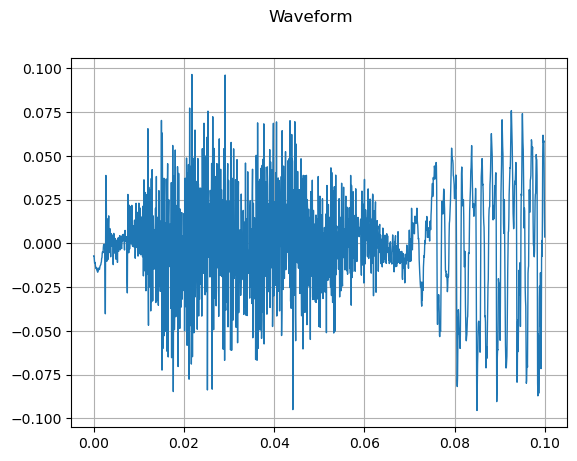

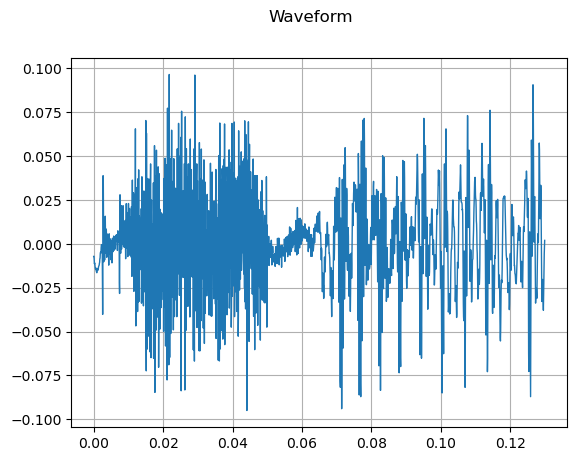

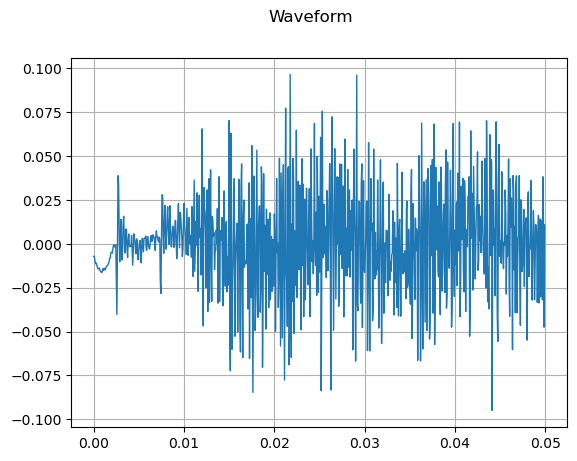

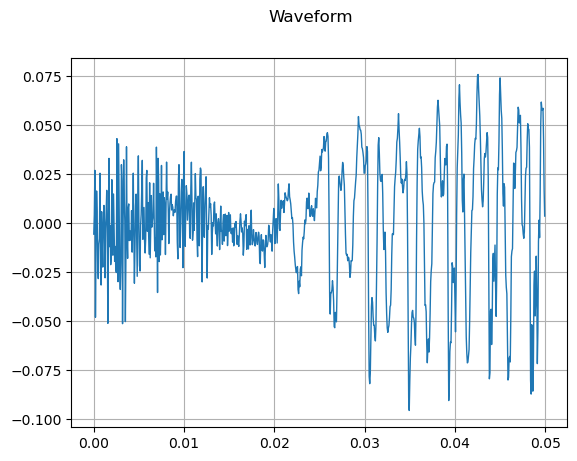

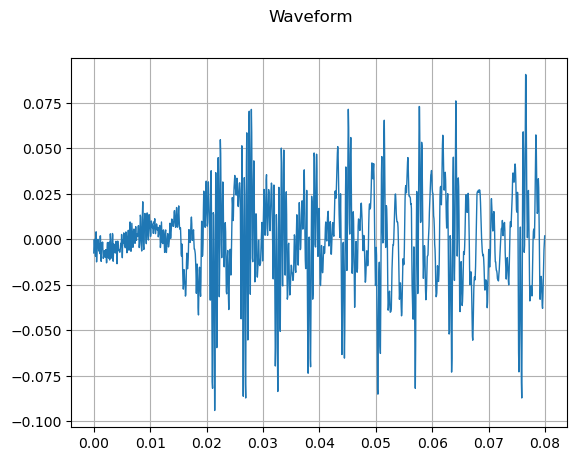

In [89]:
T_name = os.path.join(train_cut_phone_, "103/1240/0002/103-1240-0002-0169.flac")
V_name_1 = os.path.join(train_cut_phone_, "103/1240/0002/103-1240-0002-0170.flac")
V_name_2 = os.path.join(train_cut_phone_, "103/1240/0024/103-1240-0024-0013.flac")

T_data, sample_rate_T = torchaudio.load(T_name, normalize=True)
V_data_1, sample_rate_V = torchaudio.load(V_name_1, normalize=True)
V_data_2, sample_rate_V = torchaudio.load(V_name_2, normalize=True)

data_1 = torch.cat([T_data, V_data_1], dim=1)
data_2 = torch.cat([T_data, V_data_2], dim=1)

plot_waveform(data_1, sample_rate_T)
plot_waveform(data_2, sample_rate_T)

plot_waveform(T_data, sample_rate_T)
plot_waveform(V_data_1, sample_rate_T)
plot_waveform(V_data_2, sample_rate_T)

torchaudio.save("aaa_data_1.wav", data_1, sample_rate_T)
torchaudio.save("aaa_data_2.wav", data_2, sample_rate_T)
torchaudio.save("aaa_T_data.wav", T_data, sample_rate_T)
torchaudio.save("aaa_V_data_1.wav", V_data_1, sample_rate_T)
torchaudio.save("aaa_V_data_2.wav", V_data_2, sample_rate_T)

In [3]:
sibstopsdf = pd.read_csv(os.path.join(src_, "phi-ST-guide.csv"))

In [5]:
S_st = sibstopsdf["pre_startTime"]
S_et = sibstopsdf["pre_endTime"]

In [6]:
S_dur = S_et - S_st

In [12]:
np.mean(S_dur), np.std(S_dur)

(0.09068133728311471, 0.03271727752124411)

(array([ 15.,  62.,   0., 156.,  27., 209., 333.,   0., 343.,   1., 334.,
        281.,   0., 179.,  28., 109.,  79.,   0.,  70.,   7.,  36.,  22.,
          0.,  16.,   0.,  19.,   9.,   0.,   8.,   1.,   3.,   6.,   0.,
          2.,   0.,   3.,   0.,   0.,   2.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.]),
 array([0.03 , 0.036, 0.042, 0.048, 0.054, 0.06 , 0.066, 0.072, 0.078,
        0.084, 0.09 , 0.096, 0.102, 0.108, 0.114, 0.12 , 0.126, 0.132,
        0.138, 0.144, 0.15 , 0.156, 0.162, 0.168, 0.174, 0.18 , 0.186,
        0.192, 0.198, 0.204, 0.21 , 0.216, 0.222, 0.228, 0.234, 0.24 ,
        0.246, 0.252, 0.258, 0.264, 0.27 , 0.276, 0.282, 0.288, 0.294,
        0.3  , 0.306, 0.312, 0.318, 0.324, 0.33 ]),
 <BarContainer object of 50 artists>)

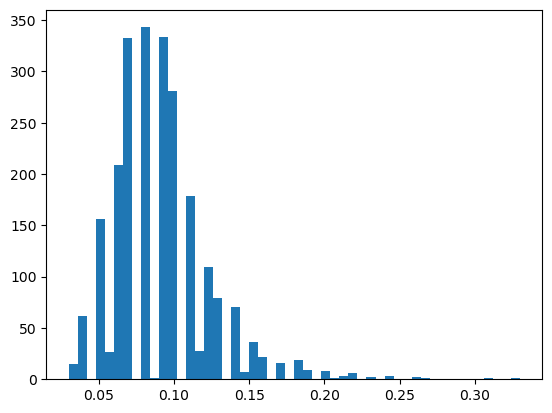

In [10]:
plt.hist(S_dur, bins='auto')

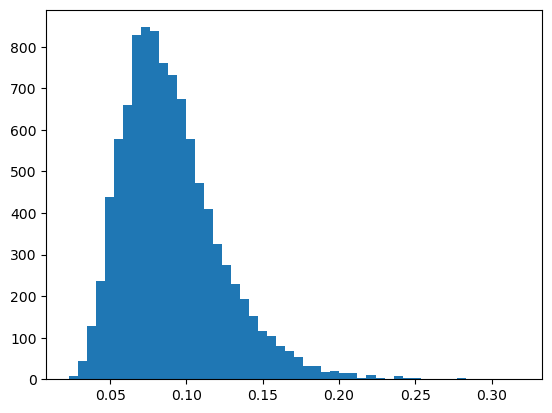

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Given mean and standard deviation
mean = 0.09068133728311471
std = 0.03271727752124411

# Generate a log-normal distribution
sigma = np.sqrt(np.log(1 + (std/mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

# Generate random samples from the log-normal distribution
samples = np.random.lognormal(mean=mu, sigma=sigma, size=10000)

# Plot the histogram of the samples
plt.hist(samples, bins=50)
plt.show()


In [4]:
class SilenceSampler_for_TV: 
    def __init__(self): 
        # mean and std fixed calculated from ST dataset. 
        mean = 0.09068133728311471
        std = 0.03271727752124411

        self.sigma = np.sqrt(np.log(1 + (std/mean)**2))
        self.mu = np.log(mean) - 0.5 * self.sigma**2
    
    def sample(self, size): 
        samples = np.random.lognormal(mean=self.mu, sigma=self.sigma, size=size)
        return samples
    

class WhiteNoiseGen: 
    def __init__(self, sample_rate, amplitude):
        self.sr = sample_rate
        self.amplitude = amplitude
    
    def generate(self, duration): 
        num_samples = int(duration * self.sr)
        noise = torch.randn(num_samples) * self.amplitude
        noise = noise.unsqueeze(0)
        return noise

In [5]:
def plot_waveform(waveform, sample_rate, title="Waveform", xlim=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].plot(time_axis, waveform[c], linewidth=1)
        axes[c].grid(True)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)


def plot_specgram(waveform, sample_rate, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, _ = waveform.shape

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)

## Now we test on level of noise

In [6]:
def plot_many(arrs, labels, save_path, plot_label_dict={"xlabel": "Epoch", "ylabel": "Value", "title": "Value Across Epochs"}): 
    n_steps = arrs[0].shape[0]
    mean_trajs = []
    lower_bounds = []
    upper_bounds = []
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    for arr in arrs: 
        assert arr.shape[0] == n_steps
        mean_traj = np.mean(arr, axis=0)
        sem_arr = sem(arr, axis=0)
        ci_95 = 1.96 * sem_arr
        upper_bound = mean_traj + ci_95
        lower_bound = mean_traj - ci_95
        mean_trajs.append(mean_traj)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    # Plotting
    plt.figure(figsize=(12, 8))
    for idx, (mean_traj, lower_bound, upper_bound, label) in enumerate(zip(mean_trajs, lower_bounds, upper_bounds, labels)): 
        plt.plot(mean_traj, label=label, color=colors[idx])
        plt.fill_between(range(n_steps), lower_bound, upper_bound, color=colors[idx], alpha=0.2)

    plt.xlabel(plot_label_dict["xlabel"])
    plt.ylabel(plot_label_dict["ylabel"])
    plt.title(plot_label_dict["title"])
    plt.legend()
    plt.grid(True)
    # plt.savefig(save_path)
    # plt.close()

In [7]:
# read in guide file
# guide_file_train = pd.read_csv(train_guide_path)
# guide_file_valid = pd.read_csv(valid_guide_path)
guide_file_test = pd.read_csv(test_guide_path)

# combine guide files
# guide_file = pd.concat([guide_file_train, guide_file_valid, guide_file_test], ignore_index=True, sort=False)
guide_file = guide_file_test

# filtering out is not necessary, since we only include wuid for encoded words
guide_file = guide_file[guide_file["segment_nostress"].isin(["sil", "sp", "spn"])]

In [8]:
sil = guide_file[guide_file["segment_nostress"].isin(["sil"])]
sp = guide_file[guide_file["segment_nostress"].isin(["sp"])]

In [9]:
sil_fns = sil["phone_path"].tolist()
sp_fns = sp["phone_path"].tolist()

In [10]:
sil_maxs = []
sil_mins = []
for fn in sil_fns: 
    wav, sr = torchaudio.load(os.path.join(train_cut_phone_, fn))
    sil_maxs.append(wav.max())
    sil_mins.append(wav.min())

sp_maxs = []
sp_mins = []
for fn in sp_fns: 
    wav, sr = torchaudio.load(os.path.join(train_cut_phone_, fn))
    sp_maxs.append(wav.max())
    sp_mins.append(wav.min())

In [11]:
def plot_tensor_histogram(tensor_list, bins=100, title="Histogram of Tensor Values", xlabel="Value", ylabel="Frequency"):
    # Convert the list of tensors to a list of values
    values = [tensor.item() for tensor in tensor_list]

    # Plot the histogram
    plt.figure(figsize=(8, 6))
    plt.hist(values, bins=bins, edgecolor='black', alpha=0.7)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

In [12]:
np.array(sil_maxs).mean(), np.array(sil_maxs).std()

(0.010987163, 0.016247552)

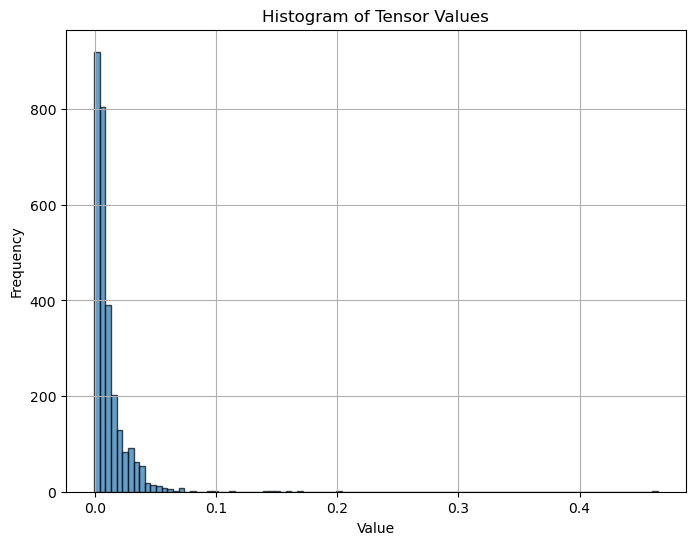

In [13]:
plot_tensor_histogram(sil_maxs)

# This tells us that the average noise level is 0.01! 
This is much higher than 1e-5. And therefore we should switch back to this low level. 

## However
Upon inspection on spectrogram, we found that 5e-4 was roughly the correct level so that the surrounding sounds would not be over-amplified nor ignored. 

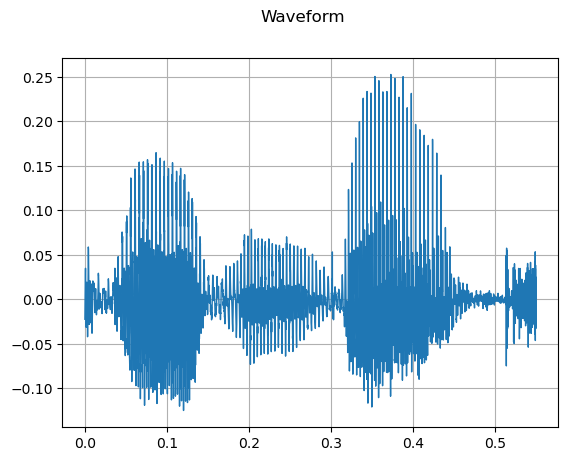

In [14]:
wav, sr = torchaudio.load(os.path.join(train_cut_phone_, "887/123291/0042/887-123291-0042-0064.flac"))
plot_waveform(wav, sr)
# plot_specgram(wav, sample_rate)

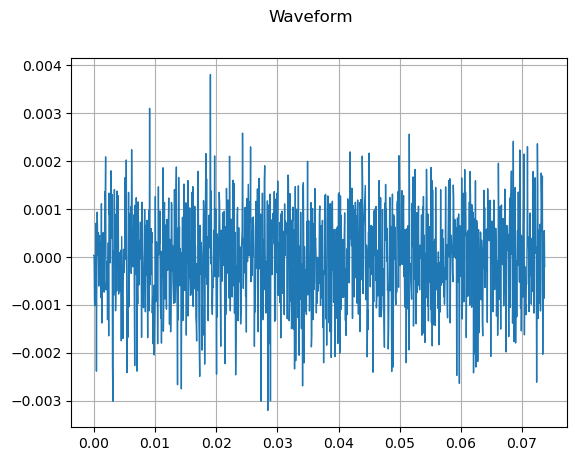

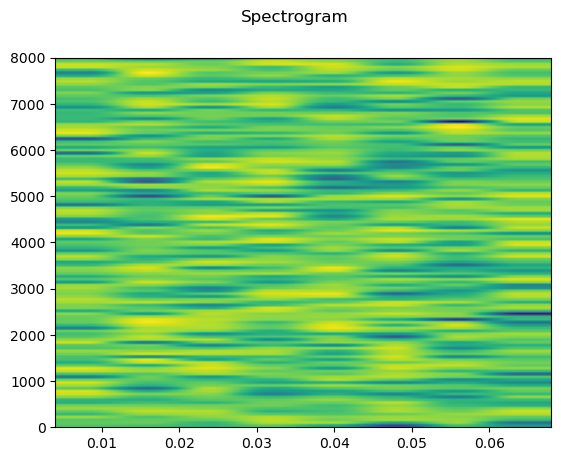

In [15]:
import torchaudio
import torch
import matplotlib.pyplot as plt

# Parameters
durations = SilenceSampler_for_TV().sample(10)
duration = durations[1]  # duration in seconds
sample_rate = 16000  # sample rate in Hz
intensity = 0.001  # intensity of the noise (amplitude scaling factor)

noise_gen = WhiteNoiseGen(sample_rate, intensity)

# Generate white noise
white_noise = noise_gen.generate(duration)


plot_waveform(white_noise, sample_rate)
plot_specgram(white_noise, sample_rate)

# Mel Investigation

In [16]:
def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title, fontsize=24)
    ax.set_ylabel(ylabel, fontdict={"fontsize": 18})
    labels = ax.get_xticklabels() + ax.get_yticklabels()
    [label.set_fontsize(18) for label in labels]
    # ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")
    ax.imshow(specgram, origin="lower", aspect="auto", interpolation="nearest")

def plot_spectrogram_lined(specgram, title=None, ylabel="freq_bin", ax=None, flines=None, dlines=None, dlines2=None, burstlines=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title, fontsize=24)
    ax.set_ylabel(ylabel, fontdict={"fontsize": 18})
    labels = ax.get_xticklabels() + ax.get_yticklabels()
    [label.set_fontsize(18) for label in labels]
    
    ax.imshow(specgram, origin="lower", aspect="auto", interpolation="nearest")
    
    # Draw vertical lines at specified x-values
    if flines is not None:
        for x in flines:
            ax.axvline(x=x, color='red', linestyle='-', linewidth=2)
    if dlines is not None:
        for x in dlines:
            ax.axvline(x=x, color='blue', linestyle='--', linewidth=1)
    if dlines2 is not None:
        for x in dlines2:
            ax.axvline(x=x, color='orange', linestyle='--', linewidth=1)
    if burstlines is not None:
        for x in burstlines:
            ax.axvline(x=x, color='purple', linestyle='dashdot', linewidth=1)

def plot_waveform(waveform, sample_rate, title="Waveform", xlim=None, flines=None, dlines=None, dlines2=None, burstlines=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].plot(time_axis, waveform[c], linewidth=1)
        axes[c].grid(True)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)
    # Draw vertical lines at specified x-values
    ax = axes[0]
    if flines is not None:
        for x in flines:
            ax.axvline(x=x, color='red', linestyle='-', linewidth=2)
    if dlines is not None:
        for x in dlines:
            ax.axvline(x=x, color='blue', linestyle='--', linewidth=1)
    if dlines2 is not None:
        for x in dlines2:
            ax.axvline(x=x, color='orange', linestyle='--', linewidth=1)
    if burstlines is not None:
        for x in burstlines:
            ax.axvline(x=x, color='purple', linestyle='dashdot', linewidth=1)
    

def frame_to_time(frame_index, sr=16000, hop_length=200):
    return frame_index * hop_length / sr

In [17]:
guide_file_valid = pd.read_csv(valid_guide_path)

In [18]:
REC_SAMPLE_RATE = 16000
N_FFT = 400
N_MELS = 64
mytrans = TheTransform(sample_rate=REC_SAMPLE_RATE, 
                    n_fft=N_FFT, n_mels=N_MELS, 
                    # normalizer=Normalizer.no_norm,
                    # denormalizer=DeNormalizer.no_norm)
                    normalizer=Normalizer.norm_mvn, 
                    denormalizer=DeNormalizer.norm_mvn)

mytrans_nonorm = TheTransform(sample_rate=REC_SAMPLE_RATE, 
                    n_fft=N_FFT, n_mels=N_MELS, 
                    normalizer=Normalizer.no_norm,
                    denormalizer=DeNormalizer.no_norm)
                    # normalizer=Normalizer.norm_mvn, 
                    # denormalizer=DeNormalizer.norm_mvn)

In [19]:
for rownum in range(guide_file_valid.shape[0]): 
    row = guide_file_valid.iloc[rownum]
    if guide_file_valid.iloc[rownum]["segment_nostress"]in ["S"] and guide_file_valid.iloc[rownum + 1]["segment_nostress"] in ["P", "T", "K"]: 
        print(f"""pre_name = os.path.join(train_cut_phone_, "{row["phone_path"]}")
T_name = os.path.join(train_cut_phone_, "{guide_file_valid.iloc[rownum + 1]["phone_path"]}")
V_name_1 = os.path.join(train_cut_phone_, "{guide_file_valid.iloc[rownum + 2]["phone_path"]}")""")
        print()
    if rownum > 2000: 
        break

pre_name = os.path.join(train_cut_phone_, "103/1240/0000/103-1240-0000-0056.flac")
T_name = os.path.join(train_cut_phone_, "103/1240/0000/103-1240-0000-0057.flac")
V_name_1 = os.path.join(train_cut_phone_, "103/1240/0000/103-1240-0000-0058.flac")

pre_name = os.path.join(train_cut_phone_, "103/1240/0000/103-1240-0000-0136.flac")
T_name = os.path.join(train_cut_phone_, "103/1240/0000/103-1240-0000-0137.flac")
V_name_1 = os.path.join(train_cut_phone_, "103/1240/0000/103-1240-0000-0138.flac")

pre_name = os.path.join(train_cut_phone_, "103/1240/0001/103-1240-0001-0131.flac")
T_name = os.path.join(train_cut_phone_, "103/1240/0001/103-1240-0001-0132.flac")
V_name_1 = os.path.join(train_cut_phone_, "103/1240/0001/103-1240-0001-0133.flac")

pre_name = os.path.join(train_cut_phone_, "103/1240/0001/103-1240-0001-0190.flac")
T_name = os.path.join(train_cut_phone_, "103/1240/0001/103-1240-0001-0191.flac")
V_name_1 = os.path.join(train_cut_phone_, "103/1240/0001/103-1240-0001-0192.flac")

pre_name

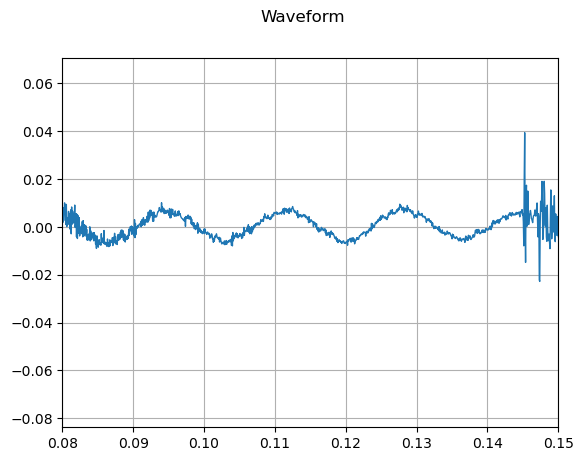

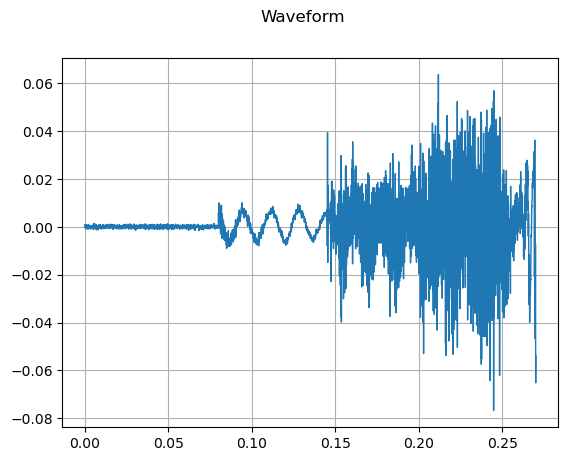

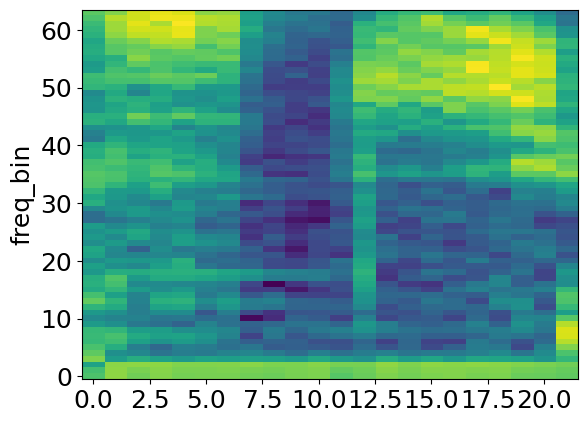

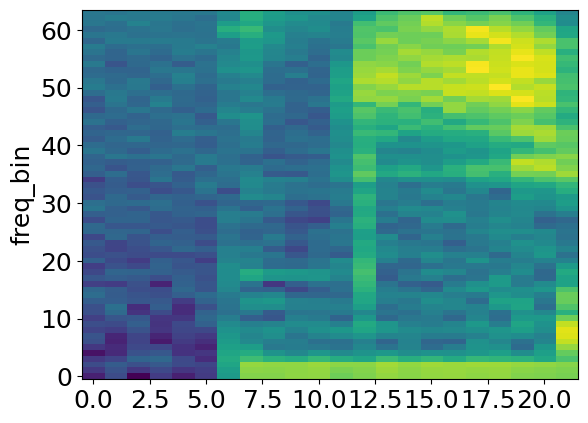

In [20]:
# pre_name = os.path.join(train_cut_phone_, "103/1240/0002/103-1240-0002-0016.flac")
# T_name = os.path.join(train_cut_phone_, "103/1240/0002/103-1240-0002-0017.flac")
# V_name_1 = os.path.join(train_cut_phone_, "103/1240/0002/103-1240-0002-0018.flac")
pre_name = os.path.join(train_cut_phone_, "103/1240/0011/103-1240-0011-0009.flac")
T_name = os.path.join(train_cut_phone_, "103/1240/0011/103-1240-0011-0010.flac")
V_name_1 = os.path.join(train_cut_phone_, "103/1240/0011/103-1240-0011-0011.flac")

pre_data, sample_rate_pre = torchaudio.load(pre_name, normalize=True)
T_data, sample_rate_T = torchaudio.load(T_name, normalize=True)
V_data_1, sample_rate_V = torchaudio.load(V_name_1, normalize=True)
# V_data_2, sample_rate_V = torchaudio.load(V_name_2, normalize=True)

sample_rate = 16000  # sample rate in Hz
intensity = 5e-4  # intensity of the noise (amplitude scaling factor)

noise_gen = WhiteNoiseGen(sample_rate, intensity)

# Generate white noise
white_noise = noise_gen.generate(pre_data.shape[1] / sample_rate_pre)

data_1 = torch.cat([pre_data, T_data, V_data_1], dim=1)
data_2 = torch.cat([white_noise, T_data, V_data_1], dim=1)

plot_waveform(data_1, sample_rate_T, xlim=(0.08, 0.15))
plot_waveform(data_2, sample_rate_T)

mel_1 = mytrans(data_1)
mel_2 = mytrans(data_2)

plot_spectrogram_lined(mel_1.T)
plot_spectrogram_lined(mel_2.T)

mel_1_nonorm = mytrans_nonorm(data_1)
mel_2_nonorm = mytrans_nonorm(data_2)

# plot_waveform(T_data, sample_rate_T)
# plot_specgram(T_data, sample_rate_T)

# plot_waveform(pre_data, sample_rate_T)
# plot_waveform(V_data_1, sample_rate_T)
# plot_waveform(V_data_2, sample_rate_T)

# torchaudio.save("001_data_1.wav", data_1, sample_rate_T)
# torchaudio.save("001_data_2.wav", data_2, sample_rate_T)
# torchaudio.save("aaa_T_data.wav", T_data, sample_rate_T)
# torchaudio.save("aaa_V_data_1.wav", V_data_1, sample_rate_T)
# torchaudio.save("aaa_V_data_2.wav", V_data_2, sample_rate_T)

In [21]:
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

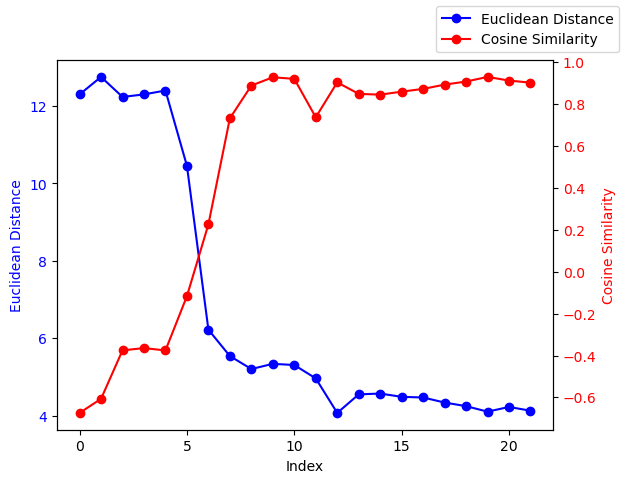

In [22]:
eucd = []
cosd = []
for i in range(len(mel_1)): 
    eucd.append(euclidean_distance(mel_1[i].numpy(), mel_2[i].numpy()))
    cosd.append(F.cosine_similarity(mel_1[i].unsqueeze(0), mel_2[i].unsqueeze(0)).item())

fig, ax1 = plt.subplots()

ax1.plot(eucd, label='Euclidean Distance', color='blue', marker="o")
ax1.set_xlabel('Index')
ax1.set_ylabel('Euclidean Distance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()
ax2.plot(cosd, label='Cosine Similarity', color='red', marker="o")
ax2.set_ylabel('Cosine Similarity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend()
plt.show()

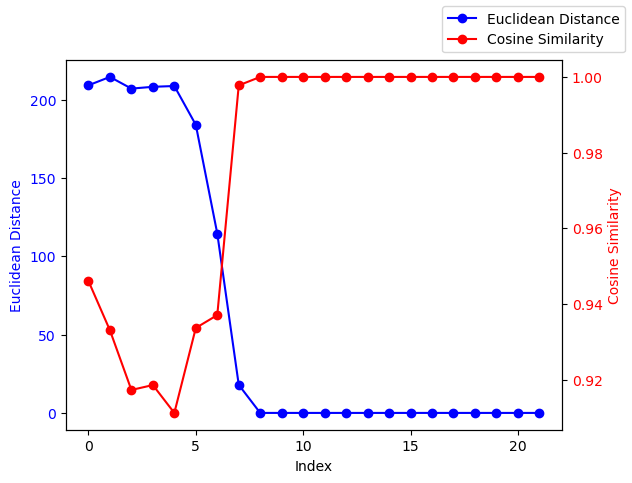

In [23]:
eucd = []
cosd = []
for i in range(len(mel_1_nonorm)): 
    eucd.append(euclidean_distance(mel_1_nonorm[i].numpy(), mel_2_nonorm[i].numpy()))
    cosd.append(F.cosine_similarity(mel_1_nonorm[i].unsqueeze(0), mel_2_nonorm[i].unsqueeze(0)).item())

fig, ax1 = plt.subplots()

ax1.plot(eucd, label='Euclidean Distance', color='blue', marker="o")
ax1.set_xlabel('Index')
ax1.set_ylabel('Euclidean Distance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(cosd, label='Cosine Similarity', color='red', marker="o")
ax2.set_ylabel('Cosine Similarity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend()
plt.show()

In [24]:
def generate_harmonic_noise(duration, sample_rate=16000, f0=60, amplitude=0.006, oscillation_amplitude=0.0001):
    t = np.linspace(0, duration, int(sample_rate*duration), endpoint=False)  # Time axis
    # Generate the dominant F0 sinusoid
    f0_signal = amplitude * np.sin(2 * np.pi * f0 * t)
    # Generate small random oscillations (noise)
    random_oscillations = oscillation_amplitude * np.random.normal(0, 1, len(t))
    # Combine the two
    combined_signal = f0_signal + random_oscillations
    return torch.tensor(combined_signal, dtype=torch.float32).unsqueeze(0)

# Test the validity of our new noise

In [25]:
def plot_spectrogram_one(specgram, title=None, ylabel="freq_bin", ax=None, vmin=None, vmax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title, fontsize=24)
    ax.set_ylabel(ylabel)
    labels = ax.get_xticklabels() + ax.get_yticklabels()
    [label.set_fontsize(18) for label in labels]
    # ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")
    ax.imshow(specgram, origin="lower", aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)

def plot_spectrogram_both(spectrogram_1, spectrogram_2, title=None, ylabel="freq_bin"):
    vmin = min(mel_1.min(), mel_2.min())
    vmax = max(mel_1.max(), mel_2.max())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    plot_spectrogram_one(spectrogram_1, title=title, ylabel=ylabel, ax=ax1, vmin=vmin, vmax=vmax)
    plot_spectrogram_one(spectrogram_2, title=title, ylabel=ylabel, ax=ax2, vmin=vmin, vmax=vmax)

/tmp/ipykernel_2838987/1701074197.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))


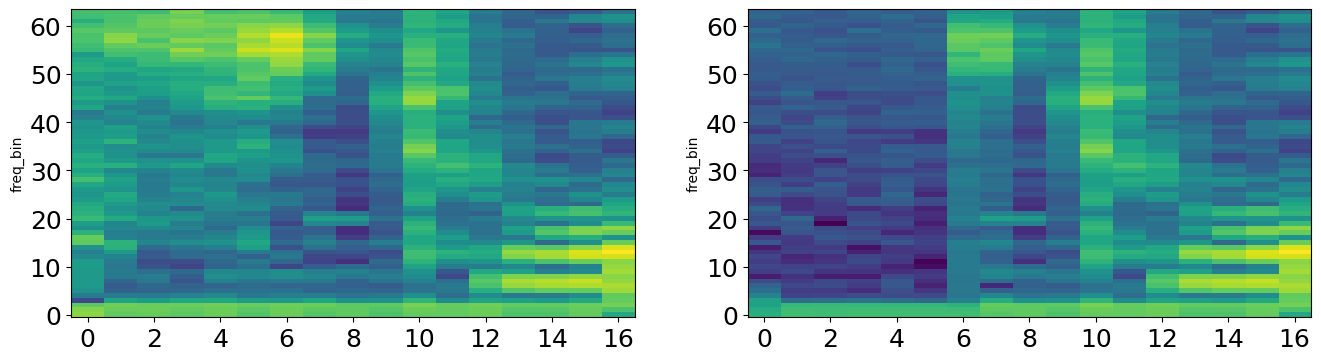

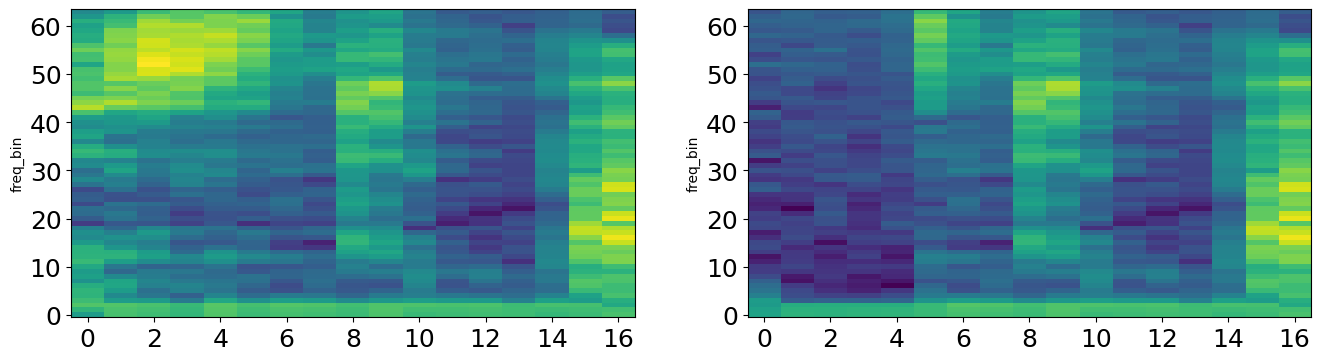

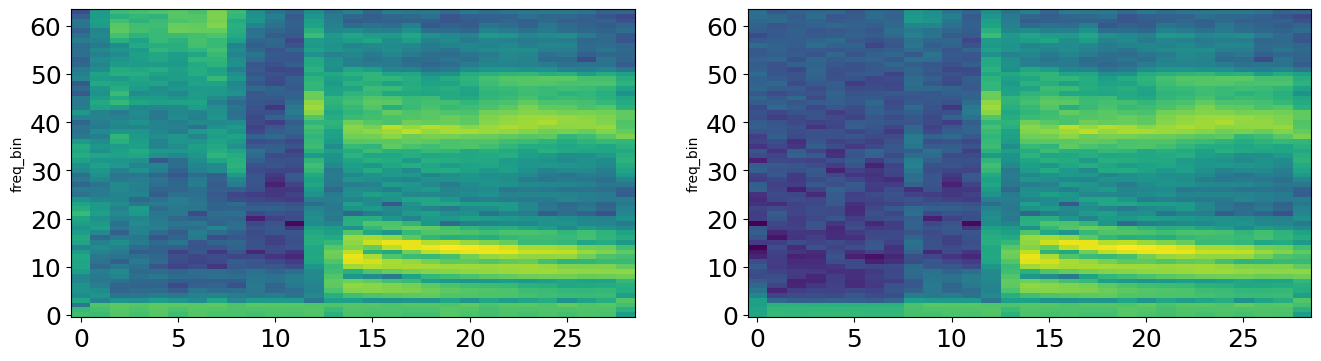

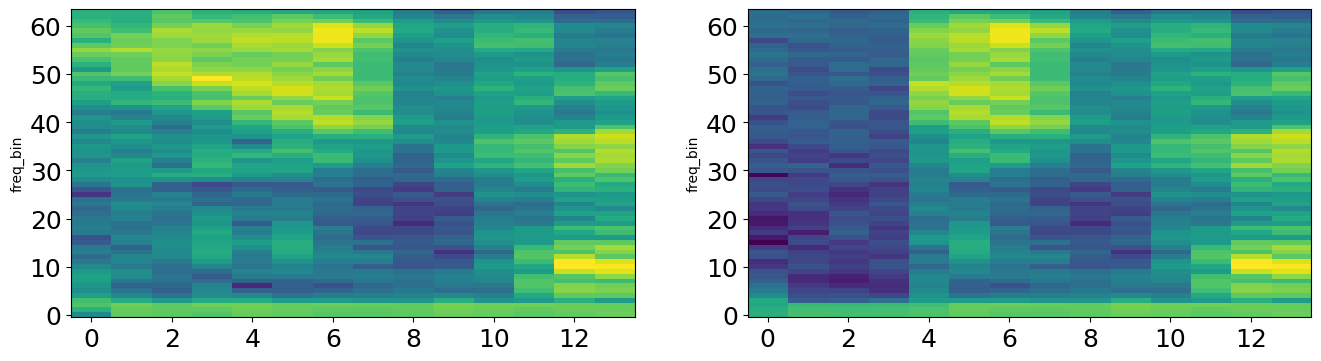

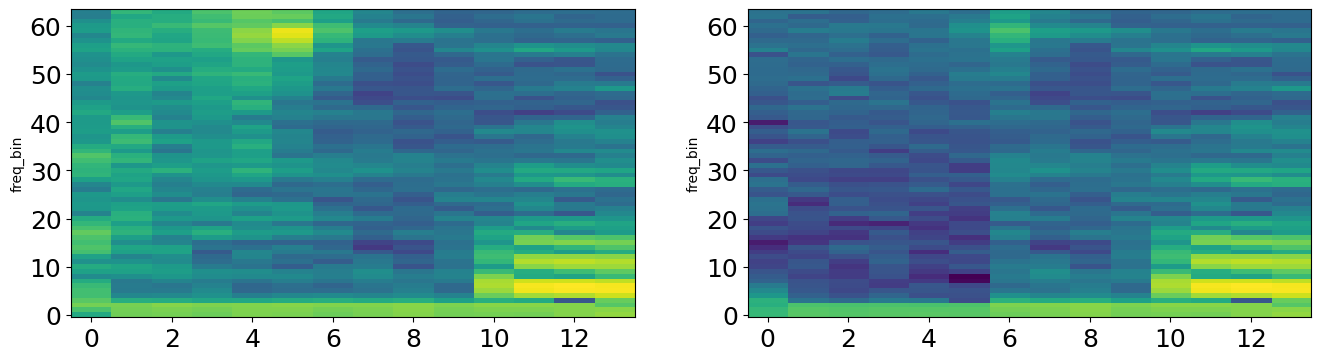

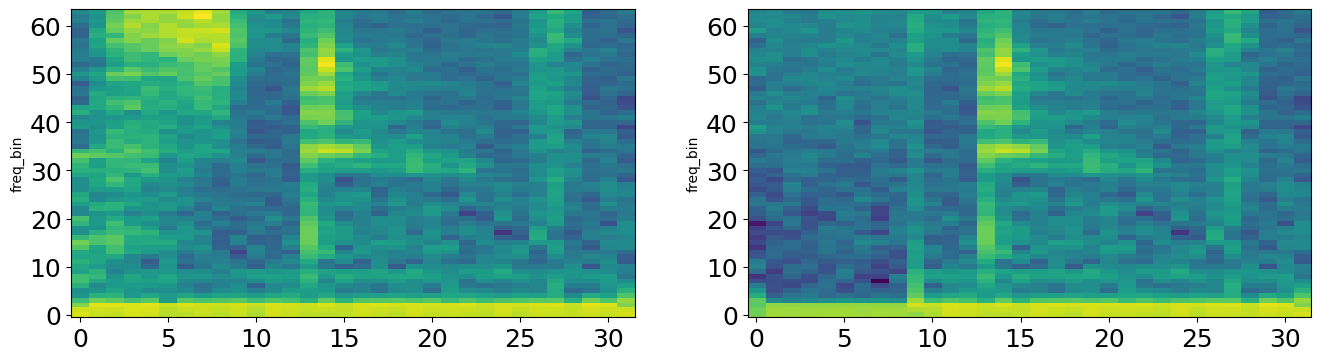

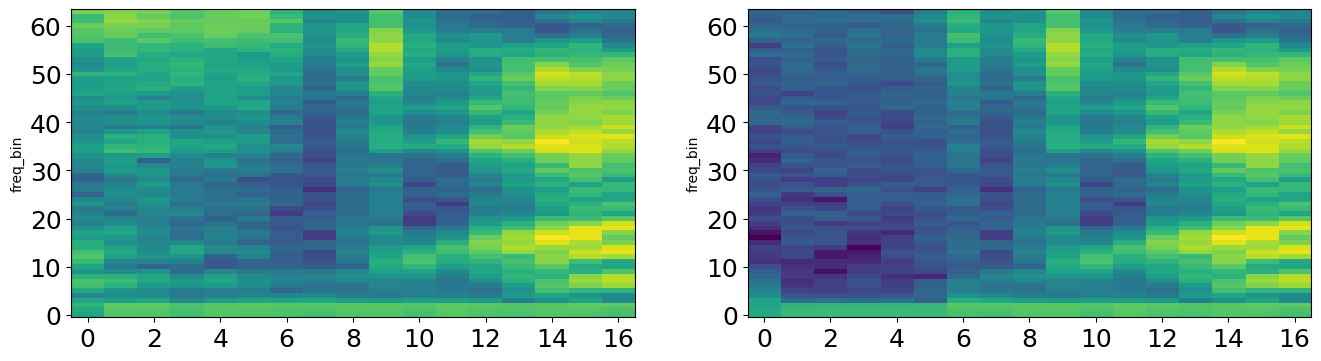

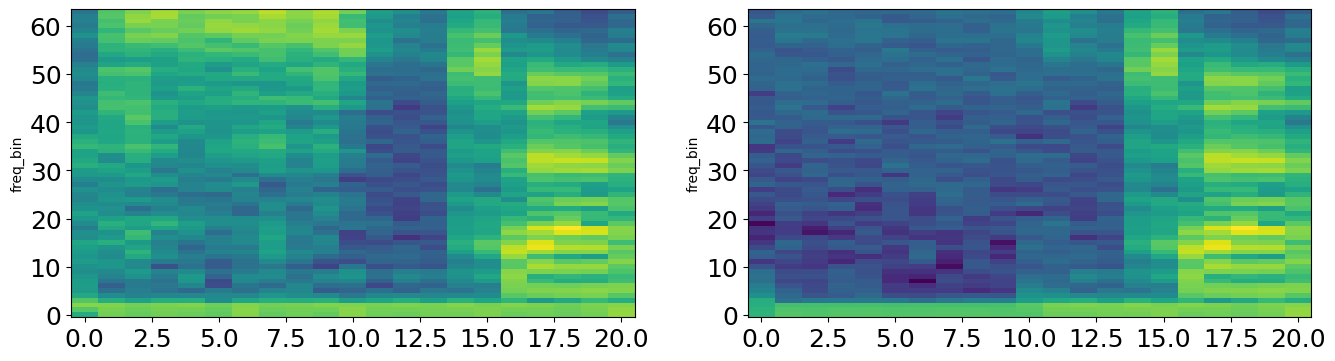

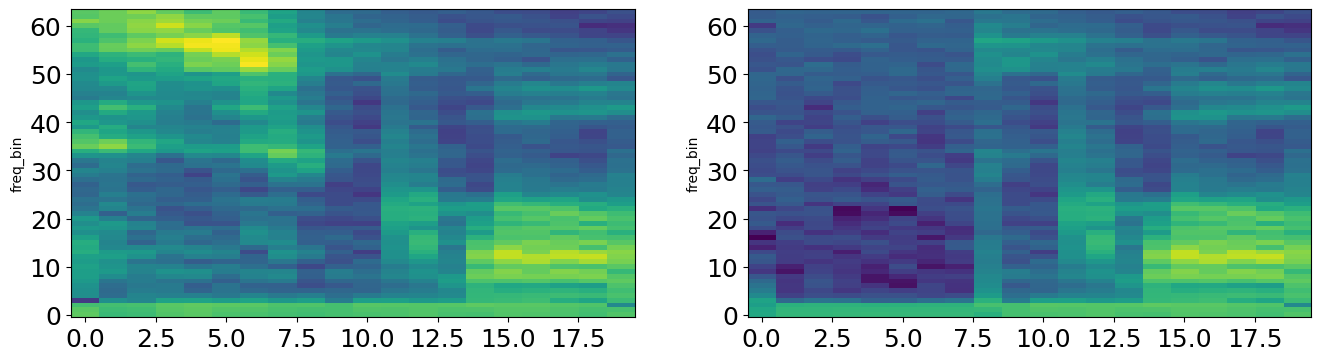

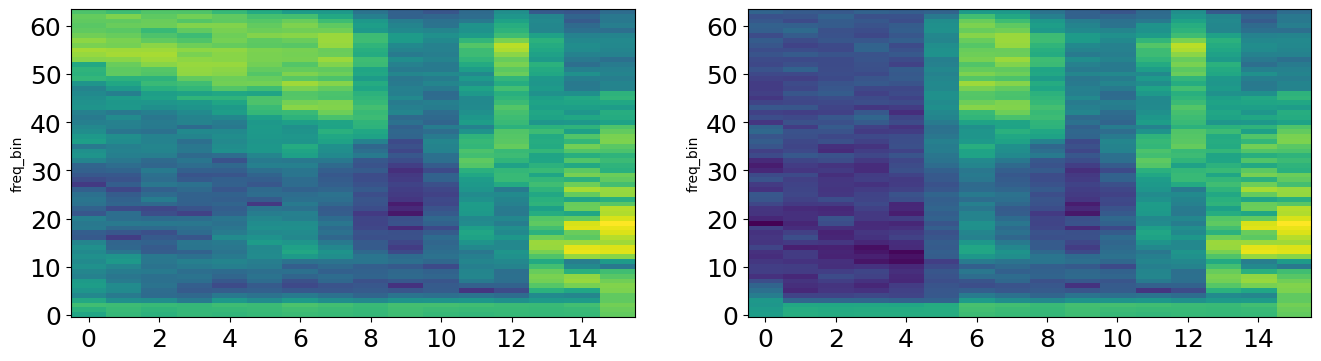

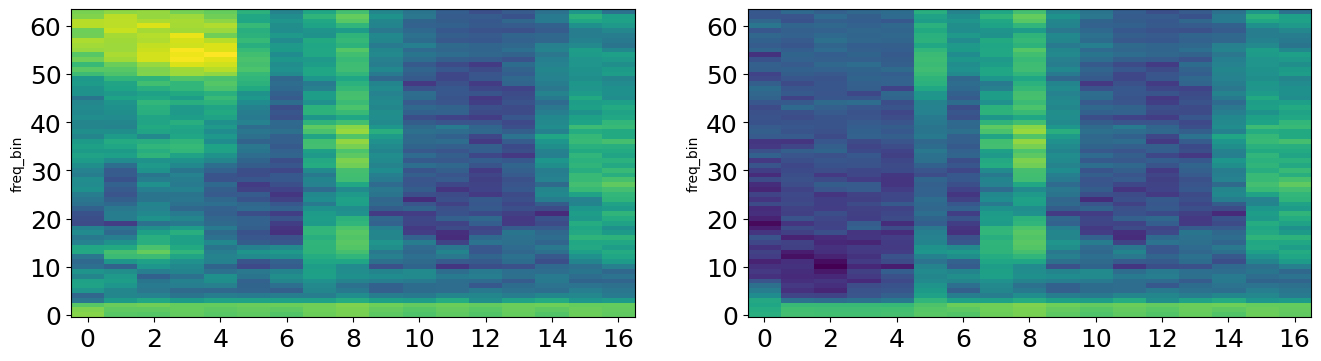

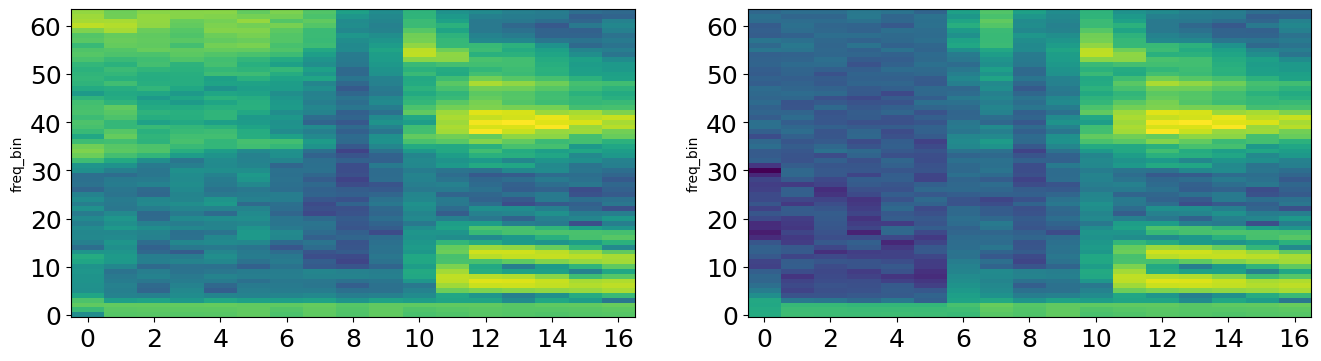

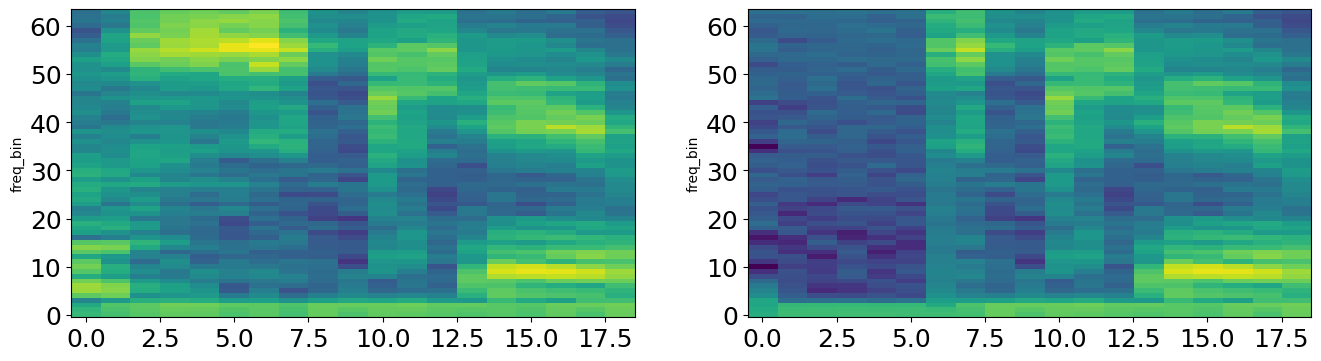

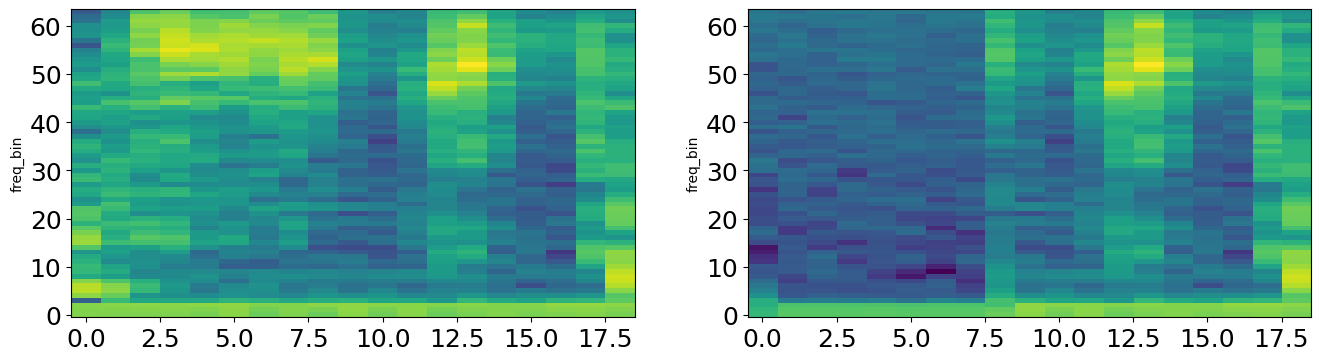

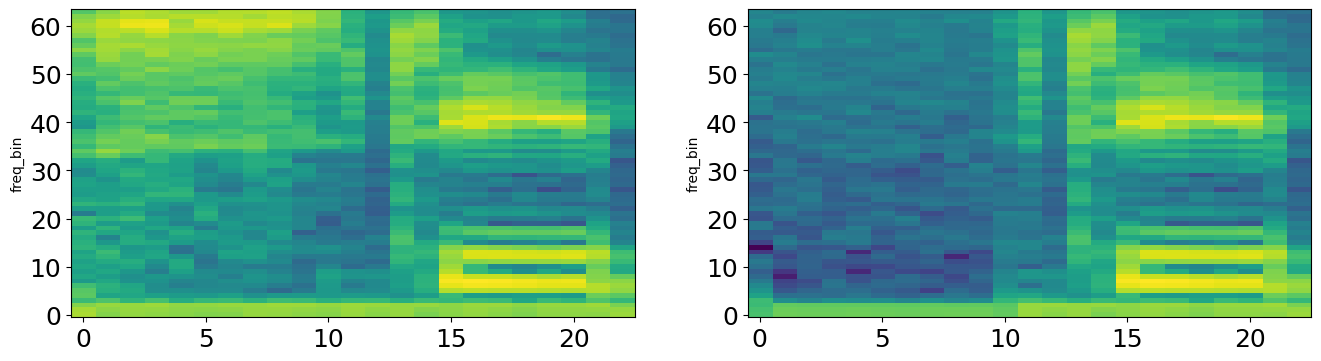

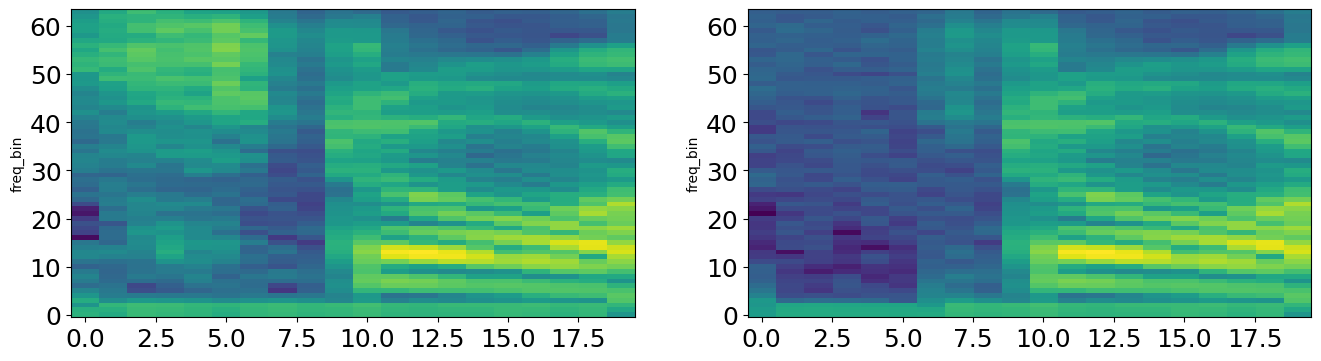

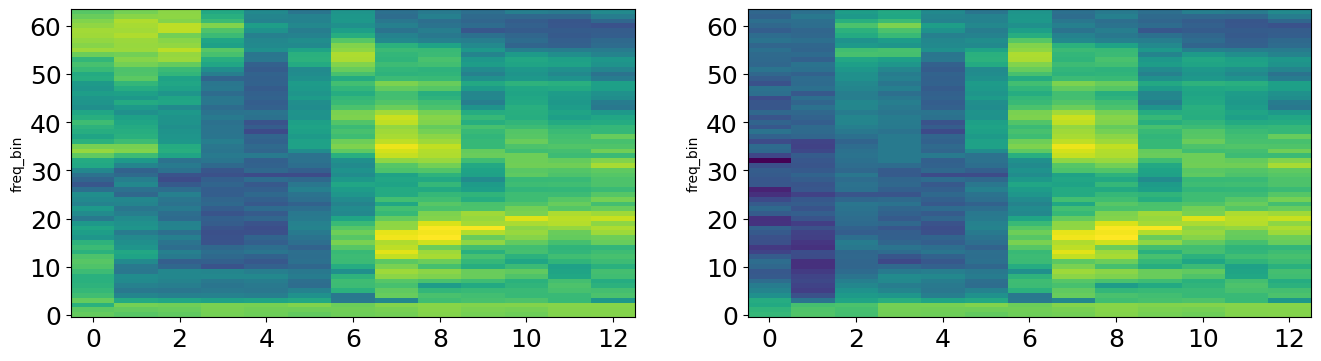

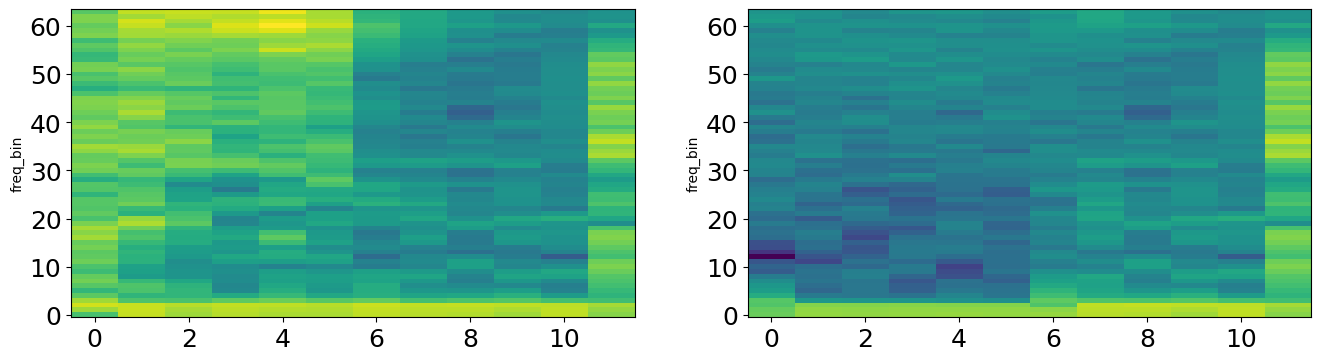

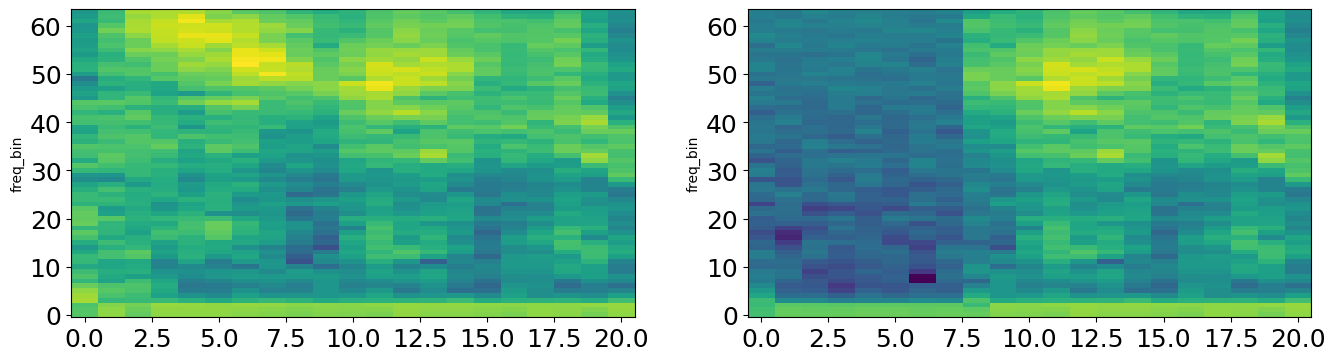

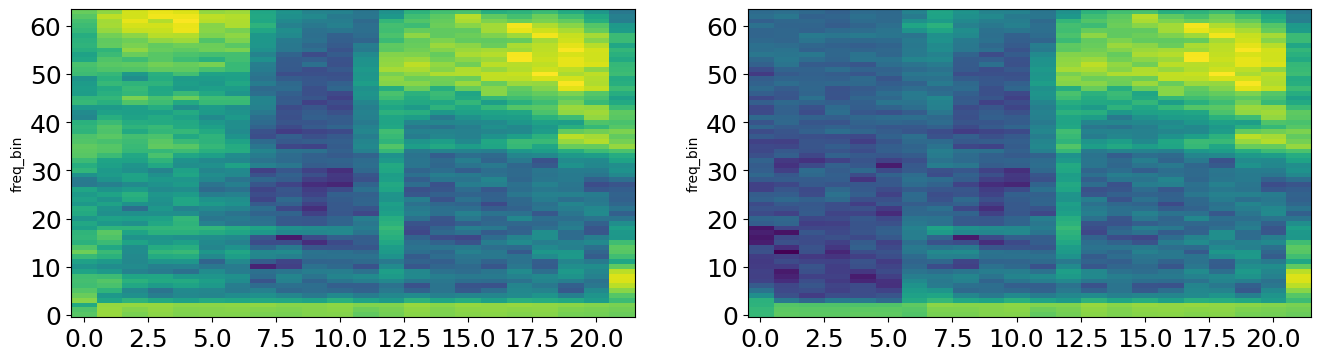

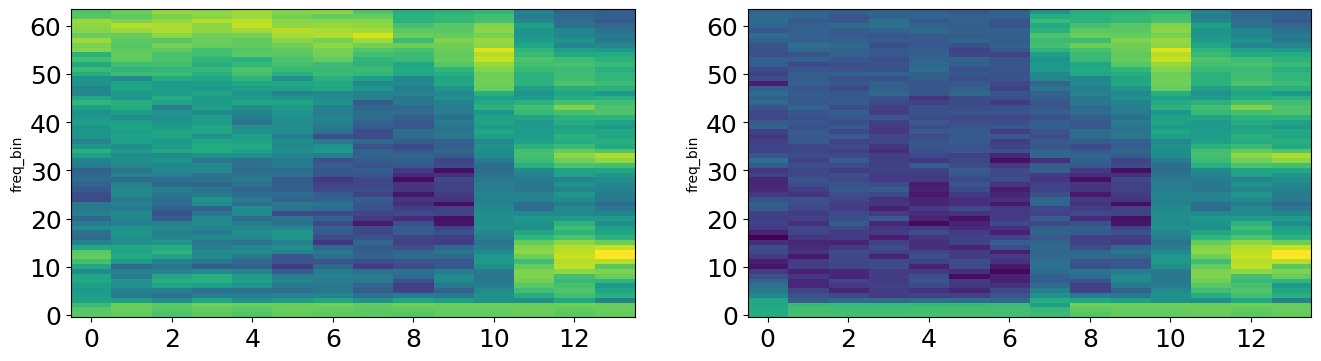

: 

In [54]:
fs = 16000  # Sampling frequency (Hz)
duration = 0.05  # Duration in seconds
f0 = 50  # Fundamental frequency (F0 in Hz)
amplitude = 0.004  # Amplitude
oscillation_amplitude = 0.0006

for rownum in range(guide_file_valid.shape[0]): 
    row = guide_file_valid.iloc[rownum]
    if guide_file_valid.iloc[rownum]["segment_nostress"]in ["S"] and guide_file_valid.iloc[rownum + 1]["segment_nostress"] in ["P", "T", "K"]: 
        pre_name = os.path.join(train_cut_phone_, row["phone_path"])
        T_name = os.path.join(train_cut_phone_, guide_file_valid.iloc[rownum + 1]["phone_path"])
        V_name_1 = os.path.join(train_cut_phone_, guide_file_valid.iloc[rownum + 2]["phone_path"])
        pre_data, sample_rate_pre = torchaudio.load(pre_name, normalize=True)
        T_data, sample_rate_T = torchaudio.load(T_name, normalize=True)
        V_data_1, sample_rate_V = torchaudio.load(V_name_1, normalize=True)

        data_1 = torch.cat([pre_data, T_data, V_data_1], dim=1)

        combined_signal = generate_harmonic_noise(pre_data.shape[1] / sample_rate_pre, 
                                                     sample_rate=fs, f0=f0, amplitude=amplitude, 
                                                     oscillation_amplitude=oscillation_amplitude)
        data_2 = torch.cat([combined_signal, T_data, V_data_1], dim=1)

        mel_1 = mytrans_nonorm(data_1)
        mel_2 = mytrans_nonorm(data_2)

        plot_spectrogram_both(mel_1.T, mel_2.T)
    if rownum > 2000: 
        break

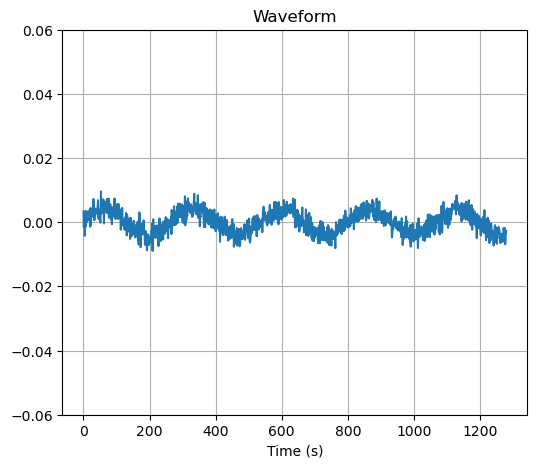

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 16000  # Sampling frequency (Hz)
duration = 0.05  # Duration in seconds
f0 = 60  # Fundamental frequency (F0 in Hz)
amplitude = 0.004  # Amplitude
oscillation_amplitude = 0.002

combined_signal = generate_harmonic_noise(pre_data.shape[1] / sample_rate_pre, sample_rate=fs, f0=f0, amplitude=amplitude, oscillation_amplitude=oscillation_amplitude)

# Plot the result (similar to the uploaded image)
plt.figure(figsize=(6, 5))
plt.plot(combined_signal[0])  # Show a portion of the signal
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylim(-0.06, 0.06)
plt.grid(True)
plt.show()

# data_3 = torch.cat([torch.tensor(combined_signal, dtype=torch.float32).unsqueeze(0), T_data, V_data_1], dim=1)

# mel_3 = mytrans(data_3)
# plot_spectrogram_lined(mel_3.T)

In [135]:
mel_1.shape, mel_2.shape, mel_3.shape

(torch.Size([22, 64]), torch.Size([22, 64]), torch.Size([22, 64]))

In [148]:
from scipy.spatial import distance

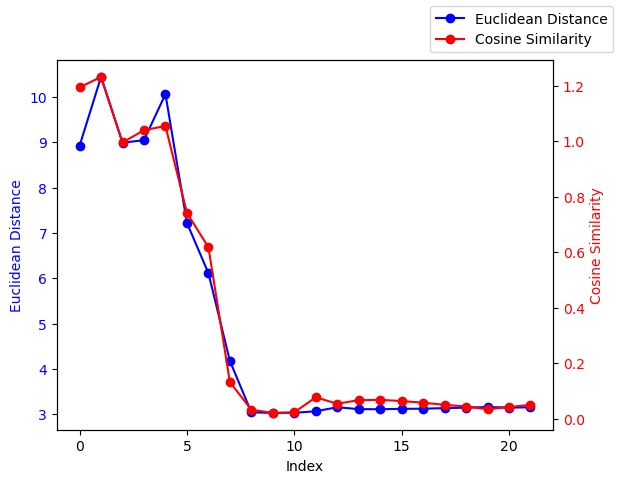

In [159]:
eucd = []
cosd = []
for i in range(len(mel_1)): 
    eucd.append(euclidean_distance(mel_1[i].numpy(), mel_3[i].numpy()))
    cosd.append(distance.cosine(mel_1[i].numpy(), mel_3[i].numpy()))
    # cosd.append(F.cosine_similarity(mel_1[i].unsqueeze(0), mel_3[i].unsqueeze(0)).item())


fig, ax1 = plt.subplots()

ax1.plot(eucd, label='Euclidean Distance', color='blue', marker="o")
ax1.set_xlabel('Index')
ax1.set_ylabel('Euclidean Distance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(cosd, label='Cosine Similarity', color='red', marker="o")
ax2.set_ylabel('Cosine Similarity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend()
plt.show()

In [207]:
i = 8
j = 12

distance.cosine(mel_1[i].numpy(), mel_3[i].numpy()), distance.cosine(mel_1[i].numpy(), mel_1[j].numpy()), euclidean_distance(mel_1[i].numpy(), mel_2[i].numpy()), euclidean_distance(mel_1[i].numpy(), mel_1[j].numpy())

(0.03219515085220337, 1.3849364817142487, 5.1044316, 12.797917)

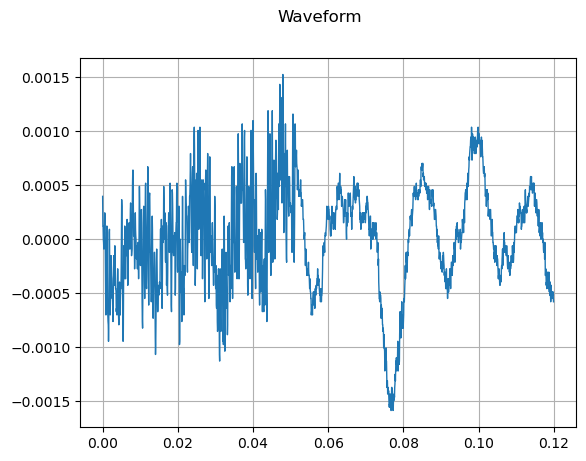

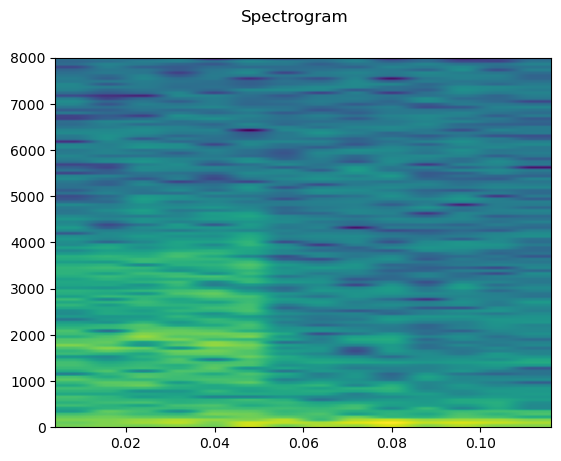

In [44]:
random_idx = random.randint(0, len(sil_fns) - 1)
fn = sil_fns[random_idx]

wav, sr = torchaudio.load(os.path.join(train_cut_phone_, fn))
plot_waveform(wav, sr)
plot_specgram(wav, sr)